# 03a - Chợ Tốt Cleaning Validation

Notebook này audit output của cleaning pipeline Chợ Tốt trước khi chuyển sang feature engineering/modeling. Mục tiêu chính không phải là làm dữ liệu đẹp bằng mọi giá, mà là tạo ra một dataset an toàn cho supervised modeling: target không bị leak vào feature, các dòng thiếu target được cách ly, các giá trị parse đáng ngờ được gắn cờ rõ ràng, và mọi cảnh báo được phân loại theo mức độ ảnh hưởng.

Notebook này có thể chỉnh nhẹ dataset đã clean để tạo artifact modeling-safe, ví dụ: set RAM đáng ngờ thành `NaN` trong numeric feature, tách quarantine cho dòng thiếu `_price`, và xuất feature list không chứa leakage. Các vấn đề chất lượng dữ liệu thật vẫn được giữ lại trong QC flag/report, không bị che giấu.

**Decision labels:**

- `PASS`: không có blocking failure và không còn warning đáng kể.
- `PASS_WITH_NON_BLOCKING_WARNINGS`: không có lỗi chặn modeling, nhưng vẫn có cảnh báo cần theo dõi trong EDA/feature engineering/modeling.
- `FAIL`: có ít nhất một lỗi blocking, ví dụ target leakage, thiếu target trong modeling-ready data, duplicate URL nếu URL phải unique, schema bắt buộc thiếu, hoặc numeric value bất khả thi chưa được flag/quarantine.

## 0. Config

Section này định nghĩa toàn bộ đường dẫn input/output và các biến modeling-safety quan trọng. Hai biến cần đọc kỹ là `target_col` và `leakage_cols`:

- `target_col = "_price"` là biến mục tiêu duy nhất cho supervised learning.
- `leakage_cols` chứa target, raw price, và mọi cột được tạo trực tiếp từ giá như `price_segment`, `is_price_outlier`, `new_low_price`, `is_price_missing`.

Những cột này có thể hữu ích để audit chất lượng dữ liệu, nhưng không được đưa vào `feature_cols`. Nếu model thấy các cột này, validation sẽ xem đó là target leakage và fail rõ ràng.

In [1]:
import os
os.environ.setdefault("PANDAS_USE_PYARROW", "0")
os.environ.setdefault("PYTHONIOENCODING", "utf-8")

import json
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    PLOTTING_AVAILABLE = True
except Exception as exc:
    PLOTTING_AVAILABLE = False
    print(f"Plotting unavailable: {exc}")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 160)

In [2]:
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data" / "intern").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
INTERN_DIR = DATA_DIR / "intern"
RAW_DIR = DATA_DIR / "raw"
DOCS_DIR = PROJECT_ROOT / "docs"

cleaned_path = INTERN_DIR / "chotot_cleaned.csv"
report_path = DOCS_DIR / "chotot_cleaning_report.csv"
action_plan_path = DOCS_DIR / "chotot_issue_action_plan.csv"
log_path = DOCS_DIR / "chotot_cleaning_log.json"
raw_path = RAW_DIR / "chotot_laptop_data.csv"

# Model-safety configuration: target and price-derived columns are never features.
target_col = "_price"
base_leakage_cols = [
    target_col,
    "price",  # raw listed price text/value before target parsing
    "raw_price",
    "price_segment",
    "is_price_outlier",
    "price_outlier",
    "new_low_price",
    "is_price_missing",
]
qc_only_cols = ["is_price_outlier", "price_outlier", "new_low_price", "is_price_missing"]
non_price_qc_feature_candidates = [
    "repair_mismatch",
    "potential_dedicated_gpu",
    "was_storage_type_imputed",
    "ram_suspicious",
]

cleaned_full_export_path = INTERN_DIR / "chotot_laptop_cleaned_full.csv"
modeling_ready_export_path = INTERN_DIR / "chotot_laptop_modeling_ready.csv"
quarantine_export_path = INTERN_DIR / "chotot_laptop_quarantine.csv"
validation_report_export_path = DOCS_DIR / "chotot_laptop_validation_report.csv"
feature_cols_export_path =DOCS_DIR / "chotot_feature_cols.json"

artifacts = {
    "cleaned_input": cleaned_path,
    "report": report_path,
    "action_plan": action_plan_path,
    "log": log_path,
    "raw_optional": raw_path,
    "cleaned_full_export": cleaned_full_export_path,
    "modeling_ready_export": modeling_ready_export_path,
    "quarantine_export": quarantine_export_path,
    "validation_report_export": validation_report_export_path,
    "feature_cols_export": feature_cols_export_path,
}

pd.DataFrame([
    {"artifact": k, "path": str(v), "exists": v.exists(), "size_bytes": v.stat().st_size if v.exists() else np.nan}
    for k, v in artifacts.items()
])

,artifact,path,exists,size_bytes
0,cleaned_input,y:\Python\Laptop-Price-Prediction\data\intern\chotot_cleaned.csv,True,3427280.0
1,report,y:\Python\Laptop-Price-Prediction\docs\chotot_cleaning_report.csv,True,7580.0
2,action_plan,y:\Python\Laptop-Price-Prediction\docs\chotot_issue_action_plan.csv,True,36180.0
3,log,y:\Python\Laptop-Price-Prediction\docs\chotot_cleaning_log.json,True,5164.0
4,raw_optional,y:\Python\Laptop-Price-Prediction\data\raw\chotot_laptop_data.csv,True,1625167.0
5,cleaned_full_export,y:\Python\Laptop-Price-Prediction\data\intern\chotot_laptop_cleaned_full.csv,False,NaN
6,modeling_ready_export,y:\Python\Laptop-Price-Prediction\data\intern\chotot_laptop_modeling_ready.csv,False,NaN
7,quarantine_export,y:\Python\Laptop-Price-Prediction\data\intern\chotot_laptop_quarantine.csv,False,NaN
8,validation_report_export,y:\Python\Laptop-Price-Prediction\docs\chotot_laptop_validation_report.csv,False,NaN
9,feature_cols_export,y:\Python\Laptop-Price-Prediction\docs\chotot_feature_cols.json,False,NaN


## 1. Load Data

Section này load các artifact từ cleaning pipeline: dataset đã clean, cleaning report, issue action plan, cleaning log, và raw data nếu có. Việc đối chiếu cleaned file với log giúp phát hiện trường hợp notebook đang audit nhầm version artifact hoặc output bị ghi đè không nhất quán.

In [3]:
cleaned = pd.read_csv(cleaned_path)
report = pd.read_csv(report_path)
action_plan = pd.read_csv(action_plan_path)
with open(log_path, "r", encoding="utf-8") as f:
    cleaning_log = json.load(f)
raw = pd.read_csv(raw_path) if raw_path.exists() else None

print(f"Cleaned shape: {cleaned.shape}")
print(f"Report shape: {report.shape}")
print(f"Action plan shape: {action_plan.shape}")
print(f"Raw file shape: {None if raw is None else raw.shape}")
print(f"Raw shape from log: {cleaning_log.get('raw_shape')}")
print(f"Cleaned shape from log: {cleaning_log.get('cleaned_shape')}")
cleaned.head(3)

Cleaned shape: (5866, 60)
Report shape: (85, 3)
Action plan shape: (96, 9)
Raw file shape: (5866, 15)
Raw shape from log: [5866, 15]
Cleaned shape from log: [5866, 60]


,url,price,title,Hãng,Dòng máy,Tình trạng,Chính sách bảo hành,Kích cỡ màn hình,Bộ vi xử lý,RAM,Card màn hình,Ổ cứng,Xuất xứ,Loại ổ cứng,_price,is_price_missing,is_price_outlier,price_segment,origin_clean,origin_missing_or_unknown,brand_clean,brand_from_title,brand_mismatch_title,model_clean,model_from_title,model_recovered,_ram_gb,_storage_gb,_screen_size_inch,_title_ram_gb,_title_storage_gb,_title_cpu,_title_screen_size_inch,_ram_gb_filled,_storage_gb_filled,_screen_size_inch_filled,ram_missing,storage_capacity_missing,screen_missing,ram_suspicious,storage_missing_all,cpu_missing,cpu_brand,cpu_tier,gpu_missing,gpu_tier,potential_dedicated_gpu,warranty_months,warranty_status,has_warranty,storage_type_clean,was_storage_type_imputed,condition_clean,new_low_price,repair_mismatch,condition_warranty_inconsistent,brand_grouped,model_grouped,brand_is_rare,model_is_rare
0,https://www.chotot.com/mua-ban-quan-tan-binh-tp-ho-chi-minh/121607693.htm,9.990.000 đ,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G,Dell,Latitude,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core i7,16 GB,Onboard,256 GB,Mỹ,SSD,9990000.0,False,False,mid,Mỹ,False,Dell,Dell,False,Latitude,Unknown,Latitude,16.0,256.0,13.95,16.0,NaN,Unknown,NaN,16.0,256.0,13.95,False,False,False,False,False,False,Intel,Upper-mid,False,Integrated - Intel,False,13.0,Active,True,SSD,False,Đã sử dụng (chưa sửa chữa),False,False,False,Dell,Latitude,False,False
1,https://www.chotot.com/mua-ban-thanh-pho-thu-dau-mot-binh-duong/130109389.htm,4.500.000 đ,Acer Aspire A315-58 i3-1115G4,Acer,Aspire A3,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i3,8 GB,Onboard,< 128 GB,Đang cập nhật,SSD,4500000.0,False,False,low,Unknown,True,Acer,Acer,False,Aspire A3,Aspire,Aspire A3,8.0,127.0,15.95,NaN,NaN,Unknown,NaN,8.0,127.0,15.95,False,False,False,False,False,False,Intel,Entry,False,Integrated - Intel,False,NaN,Manufacturer,True,SSD,False,Đã sử dụng (chưa sửa chữa),False,False,False,Acer,Other,False,True
2,https://www.chotot.com/mua-ban-quan-ha-dong-ha-noi/132012438.htm,3.500.000 đ,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1,HP,Elite X2,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,11 - 12.9 inch,Intel Core i7,8 GB,Onboard,512 GB,Đang cập nhật,SSD,3500000.0,False,False,low,Unknown,True,HP,HP,False,Elite X2,Unknown,Elite X2,8.0,512.0,11.95,NaN,NaN,Unknown,NaN,8.0,512.0,11.95,False,False,False,False,False,False,Intel,Upper-mid,False,Integrated - Intel,False,NaN,Manufacturer,True,SSD,False,Đã sử dụng (chưa sửa chữa),False,False,False,HP,Other,False,True


In [4]:
def find_col(df, candidates=(), contains=(), regex=None):
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower:
            return lower[c.lower()]
    for c in df.columns:
        cl = c.lower()
        if contains and all(tok.lower() in cl for tok in contains):
            return c
        if regex and re.search(regex, c, flags=re.I):
            return c
    return None

def bool_series(s, index=None):
    if index is None:
        index = cleaned.index
    if s is None:
        return pd.Series(False, index=index)
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.lower().isin(["true", "1", "yes", "y"])

def sample_rows(mask, cols, n=10):
    cols = [c for c in cols if c in cleaned.columns]
    out = cleaned.loc[mask, cols]
    return out.sample(n=n, random_state=42) if len(out) > n else out

def show_or_empty(df, message="No rows found."):
    if df is None or len(df) == 0:
        print(message)
    else:
        display(df)

def add_validation_check(rows, check_name, status, severity, affected_rows=0, notes=""):
    rows.append({
        "check_name": check_name,
        "status": status,
        "severity": severity,
        "affected_rows": int(affected_rows) if pd.notna(affected_rows) else np.nan,
        "notes": notes,
    })

COL = {
    "url": find_col(cleaned, ["url", "listing_url"]),
    "listing_id": find_col(cleaned, ["listing_id", "id", "item_id"]),
    "price": find_col(cleaned, [target_col, "price_clean", "price_numeric", "price"]),
    "raw_price": find_col(cleaned, ["price", "raw_price"]),
    "brand": find_col(cleaned, ["brand_clean", "Hãng", "brand"]),
    "brand_raw": find_col(cleaned, ["Hãng", "brand_raw"]),
    "model": find_col(cleaned, ["model_clean", "Dòng máy", "model"]),
    "model_raw": find_col(cleaned, ["Dòng máy", "model_raw"]),
    "ram": find_col(cleaned, ["_ram_gb_filled", "_ram_gb", "ram_gb", "RAM"]),
    "ram_raw": find_col(cleaned, ["RAM"]),
    "storage": find_col(cleaned, ["_storage_gb_filled", "_storage_gb", "storage_gb", "Ổ cứng"]),
    "storage_raw": find_col(cleaned, ["Ổ cứng"]),
    "storage_type": find_col(cleaned, ["storage_type_clean", "Loại ổ cứng", "storage_type"]),
    "cpu": find_col(cleaned, ["Bộ vi xử lý", "cpu", "_title_cpu"]),
    "cpu_brand": find_col(cleaned, ["cpu_brand"]),
    "cpu_tier": find_col(cleaned, ["cpu_tier"]),
    "gpu": find_col(cleaned, ["Card màn hình", "gpu"]),
    "gpu_tier": find_col(cleaned, ["gpu_tier"]),
    "screen": find_col(cleaned, ["_screen_size_inch_filled", "_screen_size_inch", "screen_size_inch", "Kích cỡ màn hình"]),
    "condition": find_col(cleaned, ["condition_clean", "Tình trạng", "condition"]),
    "location": find_col(cleaned, ["location", "province", "city", "origin_clean", "Xuất xứ"]),
    "title": find_col(cleaned, ["title", "Tiêu đề"]),
    "description": find_col(cleaned, ["description", "desc", "Mô tả"]),
    "price_outlier": find_col(cleaned, ["is_price_outlier", "price_outlier"]),
    "ram_suspicious": find_col(cleaned, ["ram_suspicious"]),
    "repair_mismatch": find_col(cleaned, ["repair_mismatch"]),
    "potential_dedicated_gpu": find_col(cleaned, ["potential_dedicated_gpu"]),
    "storage_type_imputed": find_col(cleaned, ["was_storage_type_imputed", "storage_type_imputed"]),
    "new_low_price": find_col(cleaned, ["new_low_price"]),
}

flag_cols = [
    c for c in cleaned.columns
    if c.startswith("is_") or c.endswith("_missing") or c.endswith("_suspicious")
    or c.endswith("_mismatch") or c.endswith("_imputed")
    or c in ["new_low_price", "potential_dedicated_gpu", "repair_mismatch", "brand_is_rare", "model_is_rare"]
]
created_cols = [c for c in cleaned.columns if raw is None or c not in raw.columns]

pd.DataFrame({"semantic_name": list(COL), "detected_column": list(COL.values())})

,semantic_name,detected_column
0,url,url
1,listing_id,None
2,price,_price
3,raw_price,price
4,brand,brand_clean
5,brand_raw,Hãng
6,model,model_clean
7,model_raw,Dòng máy
8,ram,_ram_gb_filled
9,ram_raw,RAM


In [5]:
shape_summary = pd.DataFrame([
    {"source": "raw_file", "rows": None if raw is None else raw.shape[0], "columns": None if raw is None else raw.shape[1]},
    {"source": "cleaned_file", "rows": cleaned.shape[0], "columns": cleaned.shape[1]},
    {"source": "raw_log", "rows": cleaning_log.get("raw_shape", [None, None])[0], "columns": cleaning_log.get("raw_shape", [None, None])[1]},
    {"source": "cleaned_log", "rows": cleaning_log.get("cleaned_shape", [None, None])[0], "columns": cleaning_log.get("cleaned_shape", [None, None])[1]},
])

duplicate_checks = []
for key in ["url", "listing_id"]:
    col = COL.get(key)
    if col:
        duplicate_checks.append({
            "column": col,
            "non_null": int(cleaned[col].notna().sum()),
            "duplicates": int(cleaned[col].duplicated().sum()),
            "duplicate_rate": cleaned[col].duplicated().mean(),
        })

dtype_cols = [COL[k] for k in ["price", "brand", "model", "ram", "storage", "storage_type", "cpu", "gpu", "screen", "condition", "location", "title", "description"] if COL.get(k)] + flag_cols
basic_dtype_summary = pd.DataFrame({
    "column": dtype_cols,
    "dtype": [str(cleaned[c].dtype) for c in dtype_cols],
    "missing_count": [int(cleaned[c].isna().sum()) for c in dtype_cols],
    "missing_pct": [cleaned[c].isna().mean() for c in dtype_cols],
    "nunique": [int(cleaned[c].nunique(dropna=True)) for c in dtype_cols],
})

display(shape_summary)
display(pd.DataFrame({"created_column": created_cols}))
display(pd.DataFrame(duplicate_checks))
display(basic_dtype_summary)

,source,rows,columns
0,raw_file,5866,15
1,cleaned_file,5866,60
2,raw_log,5866,15
3,cleaned_log,5866,60


,created_column
0,_price
1,is_price_missing
2,is_price_outlier
3,price_segment
4,origin_clean
5,origin_missing_or_unknown
6,brand_clean
7,brand_from_title
8,brand_mismatch_title
9,model_clean


,column,non_null,duplicates,duplicate_rate
0,url,5866,0,0.0


,column,dtype,missing_count,missing_pct,nunique
0,_price,float64,1,0.000170,718
1,brand_clean,object,0,0.000000,19
2,model_clean,object,0,0.000000,458
3,_ram_gb_filled,float64,192,0.032731,13
4,_storage_gb_filled,float64,434,0.073986,12
5,storage_type_clean,object,0,0.000000,3
6,Bộ vi xử lý,object,249,0.042448,33
7,Card màn hình,object,1421,0.242243,4
8,_screen_size_inch_filled,float64,998,0.170133,16
9,condition_clean,object,0,0.000000,3


**Nhận xét sau basic sanity check**

Kết quả shape và duplicate check là bước xác nhận đầu tiên rằng notebook đang đọc đúng artifact. Dataset cleaned hiện giữ nguyên số dòng so với raw (5,866 dòng), nghĩa là pipeline chủ yếu tạo feature/flag thay vì drop dữ liệu. Đây là hướng phù hợp cho dữ liệu marketplace vì nhiều vấn đề nên được giữ lại dưới dạng QC flag để modeling hoặc EDA quyết định sau.

Duplicate URL bằng 0 là tín hiệu tốt: mỗi listing có thể xem như một quan sát riêng. Nếu duplicate URL xuất hiện ở bước này, notebook sẽ xem đó là lỗi blocking vì cùng một listing lặp lại có thể làm sai train/test split và đánh giá model.

## 2. Validate Cleaning Log

Cleaning log là nguồn kiểm tra cấp pipeline: shape trước/sau, duplicate handling, validation flags, và số lượng rule quan trọng. Các check ở đây giúp trả lời câu hỏi: pipeline đã chạy đủ artifact chưa, row count có thay đổi bất thường không, và log có báo lỗi core nào không.

Lưu ý: log validation không thay thế validation trong notebook. Notebook vẫn tự kiểm tra lại các điều kiện modeling-safety như target leakage, missing target, và impossible numeric values.

In [6]:
validation = cleaning_log.get("validation", {})
duplicate_log = cleaning_log.get("duplicate_log", {})
issue_status_counts_log = cleaning_log.get("issue_status_counts", {})
important_rule_counts_log = cleaning_log.get("important_rule_counts", {})
config = cleaning_log.get("config", {})

raw_shape_log = tuple(cleaning_log.get("raw_shape", []))
cleaned_shape_log = tuple(cleaning_log.get("cleaned_shape", []))
row_delta = cleaned_shape_log[0] - raw_shape_log[0] if len(raw_shape_log) == 2 and len(cleaned_shape_log) == 2 else np.nan
row_drop_rate = (-row_delta / raw_shape_log[0]) if len(raw_shape_log) == 2 and raw_shape_log[0] else np.nan

rows = []
def add_check(name, expected, actual, status, comment):
    rows.append({"check_name": name, "expected_result": expected, "actual_result": actual, "status": status, "comment": comment})

required_ok = all(p.exists() for p in [cleaned_path, report_path, action_plan_path, log_path])
add_check("pipeline_artifacts_exist", "all required files exist", required_ok, "pass" if required_ok else "fail", "Required cleaning outputs are available.")
add_check("cleaned_shape_matches_file", tuple(cleaned.shape), cleaned_shape_log, "pass" if tuple(cleaned.shape) == cleaned_shape_log else "fail", "Cleaned file shape should match log.")
add_check("row_count_stability", "no abnormal row loss", f"{raw_shape_log[0]} -> {cleaned_shape_log[0]}", "pass" if row_delta == 0 else ("warn" if row_drop_rate <= 0.05 else "fail"), "Pipeline mainly flags/features rows instead of dropping records." if row_delta == 0 else f"Row delta={row_delta}.")
add_check("duplicate_url_status", "no duplicate URL after cleaning", duplicate_log.get("url_duplicate_removed"), "pass" if validation.get("no_duplicate_url", True) else "fail", "Duplicate URL status from log.")

for name, passed in validation.items():
    add_check(f"log_validation__{name}", True, passed, "pass" if bool(passed) else "fail", "Core validation check from cleaning log." if passed else "Blocking validation failure from cleaning log.")
for key, count in important_rule_counts_log.items():
    add_check(f"important_rule_count__{key}", "count recorded", count, "pass" if pd.notna(count) else "warn", "Important rule count is present for audit.")

validation_check_summary = pd.DataFrame(rows)
blocking_errors = validation_check_summary.query("status == 'fail'").copy()
display(validation_check_summary)
display(pd.DataFrame([duplicate_log]))
display(pd.DataFrame(issue_status_counts_log.items(), columns=["status", "count"]))
display(pd.DataFrame(important_rule_counts_log.items(), columns=["rule_or_flag", "count"]).sort_values("count", ascending=False))
display(blocking_errors if len(blocking_errors) else pd.DataFrame({"result": ["No blocking errors found in log validation."]}))

,check_name,expected_result,actual_result,status,comment
0,pipeline_artifacts_exist,all required files exist,True,pass,Required cleaning outputs are available.
1,cleaned_shape_matches_file,"(5866, 60)","(5866, 60)",pass,Cleaned file shape should match log.
2,row_count_stability,no abnormal row loss,5866 -> 5866,pass,Pipeline mainly flags/features rows instead of dropping records.
3,duplicate_url_status,no duplicate URL after cleaning,0,pass,Duplicate URL status from log.
4,log_validation__no_duplicate_url,True,True,pass,Core validation check from cleaning log.
5,log_validation__price_numeric,True,True,pass,Core validation check from cleaning log.
6,log_validation__invalid_price_flagged,True,True,pass,Core validation check from cleaning log.
7,log_validation__ram_numeric,True,True,pass,Core validation check from cleaning log.
8,log_validation__storage_numeric,True,True,pass,Core validation check from cleaning log.
9,log_validation__screen_numeric,True,True,pass,Core validation check from cleaning log.


,full_duplicate_removed,url_duplicate_removed
0,0,0


,status,count
0,needs_manual_review,41
1,resolved,29
2,partially_resolved,26


,rule_or_flag,count
1,price_outlier,167
3,potential_dedicated_gpu,40
6,repair_mismatch,27
5,new_low_price,25
2,ram_suspicious,23
4,storage_type_imputed,11
0,price_missing,1


,result
0,No blocking errors found in log validation.


**Nhận xét sau validation log**

Cleaning log cho thấy pipeline đã tạo đủ artifact và các check core không phát hiện lỗi chặn. Tuy nhiên log chỉ phản ánh tình trạng sau cleaning pipeline; notebook này vẫn cần kiểm tra lại các rủi ro sát modeling hơn như target leakage, missing target trong training data, và impossible numeric values.

Điểm quan trọng là không nên diễn giải “log pass” thành “data đã sẵn sàng modeling”. Data chỉ thật sự modeling-safe sau khi feature list được kiểm tra không chứa target, raw price, hoặc các cột price-derived.

## 3. Review Issue Action Plan

Issue action plan cho biết các vấn đề dữ liệu đã được xử lý, xử lý một phần, hay cần manual review. Notebook không tự động coi mọi manual-review issue là blocking, vì nhiều issue chỉ cần documentation hoặc xử lý ở feature engineering.

Cách hiểu trong notebook này:

- Vấn đề làm dataset không thể dùng để train an toàn sẽ được đưa vào blocking validation.
- Vấn đề vẫn còn nhưng có thể theo dõi bằng flag, imputation, grouping, hoặc modeling experiment sẽ là non-blocking warning.

In [7]:
issue_status_summary = action_plan.groupby("resolution_status", dropna=False).size().reset_index(name="issue_count").sort_values("issue_count", ascending=False)
issue_group_status_summary = action_plan.groupby(["issue_group", "resolution_status"], dropna=False).size().reset_index(name="issue_count").sort_values(["issue_group", "issue_count"], ascending=[True, False])
manual_review_issues = action_plan[action_plan["resolution_status"].eq("needs_manual_review")].copy()
partial_resolution_issues = action_plan[action_plan["resolution_status"].eq("partially_resolved")].copy()
high_unresolved_issues = action_plan[action_plan["severity"].eq("high") & ~action_plan["resolution_status"].eq("resolved")].copy()

def classify_issue(row):
    text = " ".join(str(row.get(c, "")) for c in ["issue_key", "affected_column", "issue_group", "issue_description", "proposed_action", "final_action"]).lower()
    if any(t in text for t in ["modeling", "encode", "encoding", "log transform", "feature"]):
        return "move_to_feature_engineering_or_modeling"
    if any(t in text for t in ["clean", "parser", "regex", "rule", "normalize", "extract", "missing", "imput"]):
        return "candidate_for_additional_cleaning_rule"
    if any(t in text for t in ["note", "lookup", "manual", "eda"]):
        return "needs_raw_or_eda_note_lookup"
    if any(t in text for t in ["document", "scope", "bias", "no row-level cleaning"]):
        return "document_or_ignore_for_modeling_scope"
    return "review_decision_needed"

manual_review_issues["validation_recommendation"] = manual_review_issues.apply(classify_issue, axis=1)
partial_resolution_issues["validation_recommendation"] = partial_resolution_issues.apply(classify_issue, axis=1)

print(f"Total issues: {len(action_plan)}")
display(issue_status_summary)
display(issue_group_status_summary)
display(high_unresolved_issues[["issue_key", "severity", "affected_column", "issue_group", "final_action", "resolution_status"]])
display(manual_review_issues["validation_recommendation"].value_counts().rename_axis("recommendation").reset_index(name="issue_count"))
display(manual_review_issues[["issue_key", "severity", "affected_column", "issue_group", "need_note_lookup", "final_action", "validation_recommendation"]])
display(partial_resolution_issues[["issue_key", "severity", "affected_column", "issue_group", "need_note_lookup", "final_action", "validation_recommendation"]])

Total issues: 96


,resolution_status,issue_count
0,needs_manual_review,41
2,resolved,29
1,partially_resolved,26


,issue_group,resolution_status,issue_count
0,brand_model_extraction_issues,needs_manual_review,10
1,brand_model_extraction_issues,resolved,4
3,columns_to_drop_keep,resolved,2
2,columns_to_drop_keep,needs_manual_review,1
4,inconsistent_categories,needs_manual_review,2
5,inconsistent_categories,resolved,2
7,invalid_values,resolved,6
6,invalid_values,needs_manual_review,2
9,missing_null_empty_values,partially_resolved,15
8,missing_null_empty_values,needs_manual_review,4


,issue_key,severity,affected_column,issue_group,final_action,resolution_status
0,price,high,price,outliers,Leave for modeling; document as modeling decision.,needs_manual_review
1,price_outliers,high,price,outliers,Create explicit flags; do not drop uncertain rows.,partially_resolved
3,title,high,title,missing_null_empty_values,Create missing indicators and conservative fallback extraction where supported.,partially_resolved
5,title_recovery,high,title,missing_null_empty_values,Apply conservative parser; never overwrite structured non-null values.,partially_resolved
29,condition_price_outliers,high,price,outliers,Create explicit flags; do not drop uncertain rows.,partially_resolved
43,screen_missing_not_random,high,Kích cỡ màn hình,missing_null_empty_values,Create missing indicators and conservative fallback extraction where supported.,partially_resolved
44,screen_recovery_low_coverage,high,Kích cỡ màn hình,missing_null_empty_values,Apply conservative parser; never overwrite structured non-null values.,partially_resolved
47,screen_imputation_risk,high,Kích cỡ màn hình,missing_null_empty_values,Documented; no deterministic cleaning required.,needs_manual_review
52,cpu_missing_not_random,high,Bộ vi xử lý,missing_null_empty_values,Create missing indicators and conservative fallback extraction where supported.,partially_resolved
55,high_price_outliers_explainable,high,price,outliers,Create explicit flags; do not drop uncertain rows.,partially_resolved


,recommendation,issue_count
0,move_to_feature_engineering_or_modeling,29
1,candidate_for_additional_cleaning_rule,12


,issue_key,severity,affected_column,issue_group,need_note_lookup,final_action,validation_recommendation
0,price,high,price,outliers,yes,Leave for modeling; document as modeling decision.,move_to_feature_engineering_or_modeling
2,price_market_bias,medium,price,price_related_issues,no,Document local-market scope; no row-level cleaning.,candidate_for_additional_cleaning_rule
4,title_parsing,low,title,text_normalization_specs_parsing,no,Documented; no deterministic cleaning required.,candidate_for_additional_cleaning_rule
8,title_cpu_coverage,low,title,text_normalization_specs_parsing,yes,Documented; no deterministic cleaning required.,move_to_feature_engineering_or_modeling
10,brand_sample_bias,medium,Hãng,outliers,no,Leave for modeling; document as modeling decision.,move_to_feature_engineering_or_modeling
13,model_high_cardinality,low,Dòng máy,brand_model_extraction_issues,no,Leave for modeling; document as modeling decision.,move_to_feature_engineering_or_modeling
17,model_brand_dependency,low,Hãng,brand_model_extraction_issues,no,Leave for modeling; document as modeling decision.,move_to_feature_engineering_or_modeling
20,model_name_inconsistency,medium,Dòng máy,text_normalization_specs_parsing,no,Documented; no deterministic cleaning required.,move_to_feature_engineering_or_modeling
24,model_as_segment_indicator,low,Dòng máy,brand_model_extraction_issues,no,Documented; no deterministic cleaning required.,move_to_feature_engineering_or_modeling
26,new_low_price_inconsistency,medium,price,outliers,no,Leave for modeling; document as modeling decision.,move_to_feature_engineering_or_modeling


,issue_key,severity,affected_column,issue_group,need_note_lookup,final_action,validation_recommendation
1,price_outliers,high,price,outliers,yes,Create explicit flags; do not drop uncertain rows.,review_decision_needed
3,title,high,title,missing_null_empty_values,yes,Create missing indicators and conservative fallback extraction where supported.,move_to_feature_engineering_or_modeling
5,title_recovery,high,title,missing_null_empty_values,yes,Apply conservative parser; never overwrite structured non-null values.,candidate_for_additional_cleaning_rule
6,title_consistency,low,title,missing_null_empty_values,no,Create missing indicators and conservative fallback extraction where supported.,candidate_for_additional_cleaning_rule
7,title_structure,low,title,text_normalization_specs_parsing,yes,Apply conservative parser; never overwrite structured non-null values.,candidate_for_additional_cleaning_rule
15,dong_khac_information_loss,low,Dòng máy,text_normalization_specs_parsing,yes,Apply conservative parser; never overwrite structured non-null values.,candidate_for_additional_cleaning_rule
16,dong_khac_recoverable_from_title,low,title,text_normalization_specs_parsing,yes,Apply conservative parser; never overwrite structured non-null values.,candidate_for_additional_cleaning_rule
29,condition_price_outliers,high,price,outliers,yes,Create explicit flags; do not drop uncertain rows.,review_decision_needed
34,semantic_signal_vs_structured,low,NaN,text_normalization_specs_parsing,yes,Apply conservative parser; never overwrite structured non-null values.,candidate_for_additional_cleaning_rule
43,screen_missing_not_random,high,Kích cỡ màn hình,missing_null_empty_values,yes,Create missing indicators and conservative fallback extraction where supported.,candidate_for_additional_cleaning_rule


**Nhận xét sau issue action plan**

Issue action plan vẫn còn các mục manual review/partially resolved, nhưng không phải tất cả đều chặn modeling. Notebook phân biệt rõ: nếu issue làm dataset sai về mặt supervised learning thì đưa vào blocking validation; nếu issue chỉ cần theo dõi, grouping, imputation hoặc thử nghiệm modeling thì giữ là non-blocking warning.

Cách đọc bảng này: các issue chưa xử lý xong là backlog chất lượng dữ liệu, không phải lý do tự động drop row. Việc drop quá tay có thể làm mất tín hiệu thật của thị trường laptop cũ.

## 4. QC Flags - Missing Values

Section này kiểm tra missing values ở các trường quan trọng. Với feature thông thường, missing value không nhất thiết là lỗi blocking vì có thể xử lý bằng imputation, missing indicator, hoặc encoder ở bước feature engineering.

Riêng `_price` là target nên được xử lý nghiêm hơn: dòng thiếu `_price` không được xuất hiện trong modeling-ready dataset. Những dòng này được giữ lại trong quarantine để audit, không bị xóa mất dấu.

In [8]:
missing_candidates = {
    "price": COL["price"], "brand": COL["brand"], "model": COL["model"], "RAM": COL["ram"], "storage": COL["storage"],
    "storage_type": COL["storage_type"], "CPU": COL["cpu"], "GPU": COL["gpu"], "screen_size": COL["screen"],
    "condition/status": COL["condition"], "location": COL["location"], "title": COL["title"], "description": COL["description"],
}
rows = []
for label, col in missing_candidates.items():
    if col and col in cleaned.columns:
        rows.append({
            "field": label, "column": col, "missing_count": int(cleaned[col].isna().sum()),
            "missing_pct": cleaned[col].isna().mean(), "nunique": int(cleaned[col].nunique(dropna=True)),
            "recommended_handling": (
                "blocking: target rows need exclusion or repair" if label == "price" and cleaned[col].isna().sum() > 0 else
                "keep NaN + missing flag / Unknown only at encoding time" if label in ["brand", "model", "storage_type", "CPU", "GPU", "condition/status", "location"] else
                "keep NaN for numeric feature; add missing indicator" if label in ["RAM", "storage", "screen_size"] else
                "audit/NLP source; do not use raw text directly in baseline"
            ),
        })
missing_value_summary = pd.DataFrame(rows).sort_values("missing_pct", ascending=False)
top_missing_columns = cleaned.isna().sum().rename("missing_count").reset_index().rename(columns={"index": "column"})
top_missing_columns["missing_pct"] = top_missing_columns["missing_count"] / len(cleaned)
top_missing_columns = top_missing_columns.sort_values("missing_pct", ascending=False).head(25)

missing_before_after = report[report["section"].eq("missing_before_after")].copy() if {"section", "metric", "value"}.issubset(report.columns) else pd.DataFrame()
if len(missing_before_after):
    parsed = missing_before_after["value"].apply(lambda x: pd.Series(json.loads(x)))
    missing_before_after = pd.concat([missing_before_after[["metric"]], parsed], axis=1)
    missing_before_after["delta_after_minus_before"] = missing_before_after["after"] - missing_before_after["before"]

display(missing_value_summary)
display(top_missing_columns)
display(missing_before_after)

,field,column,missing_count,missing_pct,nunique,recommended_handling
7,GPU,Card màn hình,1421,0.242243,4,keep NaN + missing flag / Unknown only at encoding time
8,screen_size,_screen_size_inch_filled,998,0.170133,16,keep NaN for numeric feature; add missing indicator
4,storage,_storage_gb_filled,434,0.073986,12,keep NaN for numeric feature; add missing indicator
6,CPU,Bộ vi xử lý,249,0.042448,33,keep NaN + missing flag / Unknown only at encoding time
3,RAM,_ram_gb_filled,192,0.032731,13,keep NaN for numeric feature; add missing indicator
0,price,_price,1,0.000170,718,blocking: target rows need exclusion or repair
1,brand,brand_clean,0,0.000000,19,keep NaN + missing flag / Unknown only at encoding time
2,model,model_clean,0,0.000000,458,keep NaN + missing flag / Unknown only at encoding time
5,storage_type,storage_type_clean,0,0.000000,3,keep NaN + missing flag / Unknown only at encoding time
9,condition/status,condition_clean,0,0.000000,3,keep NaN + missing flag / Unknown only at encoding time


,column,missing_count,missing_pct
32,_title_screen_size_inch,4111,0.700818
47,warranty_months,3392,0.578248
30,_title_storage_gb,2730,0.465394
29,_title_ram_gb,1621,0.276338
10,Card màn hình,1421,0.242243
28,_screen_size_inch,1037,0.176781
7,Kích cỡ màn hình,1037,0.176781
35,_screen_size_inch_filled,998,0.170133
13,Loại ổ cứng,726,0.123764
27,_storage_gb,470,0.080123


,metric,before,after,delta_after_minus_before
14,Bộ vi xử lý,249.0,249.0,0.0
15,Card màn hình,1421.0,1421.0,0.0
16,Chính sách bảo hành,0.0,0.0,0.0
17,Dòng máy,0.0,0.0,0.0
18,Hãng,0.0,0.0,0.0
...,...,...,...,...
70,url,0.0,0.0,0.0
71,warranty_months,NaN,3392.0,NaN
72,warranty_status,NaN,0.0,NaN
73,was_storage_type_imputed,NaN,0.0,NaN


**Nhận xét sau missing value summary**

Missing value ở feature không nhất thiết là lỗi nghiêm trọng, vì model có thể xử lý bằng imputation, missing indicator hoặc encoder phù hợp. Riêng _price là target nên có quy tắc khác: dòng thiếu target không thể dùng cho supervised training.

Vì vậy notebook không xóa âm thầm dòng thiếu _price; dòng đó được đưa vào quarantine để audit. Cách làm này vừa giữ được traceability, vừa đảm bảo modeling-ready dataset không có target rỗng.

## 5. Cleaning Pipeline - Target Price

Target price là điểm dễ gây leakage nhất. Section này chuyển `_price` sang numeric, đếm dòng thiếu target, và tạo quarantine mask cho những dòng không thể dùng trong supervised training.

Quyết định xử lý:

- Dòng thiếu `_price` được loại khỏi modeling-ready artifact.
- Dòng bị price outlier hoặc `new_low_price` không bị drop tự động, vì đây có thể là dữ liệu thật hoặc cần model robust hơn.
- Các flag có nguồn gốc từ price chỉ dùng cho QC/reporting, không dùng làm feature. Đây là điểm quan trọng vì model không thể biết `price_outlier` hay `price_segment` tại thời điểm dự đoán nếu chưa biết giá thật.

Target handling summary
Rows before removal: 5,866
Rows removed due to missing _price: 1
Rows remaining for modeling: 5,865


,target_column,raw_price_column,rows_before_target_filter,rows_removed_due_to_missing_target,rows_remaining_after_target_filter,target_missing,non_positive,below_1000000,above_60000000,flagged_price_outlier,flagged_new_low_price,min,max,mean,median,p01,p99
0,_price,price,5866,1,5865,1,0,159,8,167,25,6500.0,99900000.0,9.915058e+06,7600000.0,600000.0,39644000.0


,price_bin,count,pct
0,mid,1968,0.335493
1,low,1788,0.304807
2,high,1543,0.263041
3,premium,566,0.096488
4,NaN,1,0.000170


,title,_price,brand_clean,model_clean,_ram_gb_filled,_storage_gb_filled,condition_clean,origin_clean,is_price_outlier
3357,Lenovo B470e 4GB/500GB Không vào Win,400000.0,Lenovo,Dòng Khác,4.0,500.0,Đã sử dụng (qua sửa chữa),Unknown,True
3613,IBM X60S Đen Đã qua sử dụng,200000.0,Hãng khác,Dòng Khác,NaN,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True
2324,Củ sạc Apple 67W MagSafe 2,650000.0,Apple,MacBook,NaN,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True
1550,Thanh lý Laptop Toshiba Satelite L840 core I3,950000.0,Toshiba,Satellite Series,4.0,128.0,Đã sử dụng (chưa sửa chữa),Unknown,True
3212,Apple MacBook Pro 16 inch M5 Pro 24GB/1TB,67500000.0,Apple,Dòng Khác,16.0,1024.0,Đã sử dụng (chưa sửa chữa),Unknown,True
775,Asus A510b i3 gen 8 8GB DDR4 Vàng,999000.0,ASUS,Dòng Khác,8.0,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True
3469,Dell N4010 i3 4GB/500GB Đỏ,500000.0,Dell,Dòng Khác,4.0,500.0,Đã sử dụng (chưa sửa chữa),Unknown,True
2419,thanh lý macbook,14500.0,Dell,Dòng Khác,16.0,512.0,Đã sử dụng (chưa sửa chữa),Unknown,True
3462,MACBOOK PRO 2019 NHƯ MỚI,850000.0,Apple,MacBook Pro,8.0,250.0,Đã sử dụng (chưa sửa chữa),Việt Nam,True
3622,Laptop Lenovo thế hệ4 pin3h ram 4G SSD64G 14in bền,990000.0,Lenovo,Ideapad 100,4.0,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True


,title,_price,brand_clean,model_clean,_ram_gb_filled,_storage_gb_filled,condition_clean,origin_clean,new_low_price
2339,"Dell Inspiron 3505 R5-3500U, RAM 8GB, SSD 512GB",4200000.0,Dell,Inspiron 15 3000,8.0,512.0,Mới,Other,True
3298,Asus i3-8145U 8GB/256GB 14 inch fullhd,2600000.0,ASUS,Vivobook 14,8.0,256.0,Mới,Việt Nam,True
26,"HP 15-da0056TU i3 8130U, 4GB, SSD 128GB, 15.6"" HD",2300000.0,HP,Dòng Khác,4.0,128.0,Mới,Other,True
5806,Lenovo IdeaPad 3 Chromebook 14M836,4700000.0,Lenovo,ChromeBook,4.0,NaN,Mới,Mỹ,True
2865,Dell Inspiron 3593 i5-1035G1/8GB/240GB/MX230 2GB,4500000.0,Dell,Inspiron,8.0,250.0,Mới,Other,True
2375,Bán Macbook Pro Retina 2015 Core i7 15inch đẹp 99%,4550000.0,Apple,MacBook Pro,8.0,500.0,Mới,Mỹ,True
3076,"Dell Vostro 3468 Core i3-6006U, RAM 4GB, SSD 120GB",1800000.0,Dell,Dòng Khác,4.0,128.0,Mới,Other,True
28,Macbook 12 inch retina 2017,4000000.0,Apple,MacBook,8.0,256.0,Mới,Mỹ,True
5753,Dell Vostro 3568 Core i7-7500U/8GB/240GB/R5 M420,4300000.0,Dell,Vostro,8.0,250.0,Mới,Other,True
1667,LAPTOP DELL I5 - MỚI 100% - GÓP NHANH,2300000.0,Dell,Dòng Khác,8.0,512.0,Mới,Mỹ,True


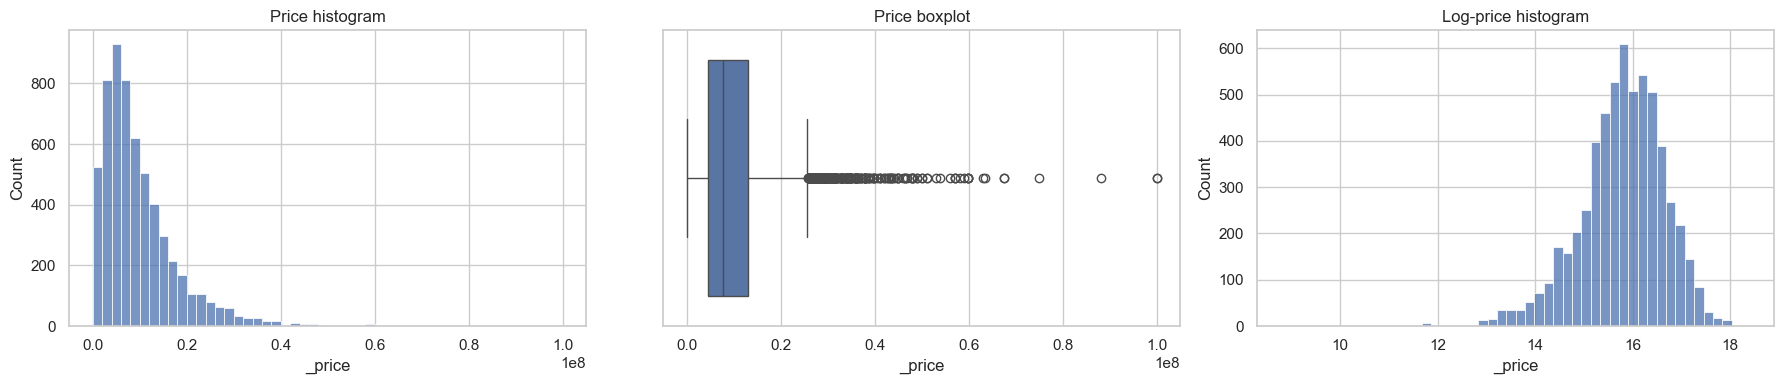

,question,finding,decision
0,Missing target,1 row(s) have missing _price.,Quarantine these rows; do not use them for supervised modeling.
1,Outlier handling,"Outliers are flagged, not dropped.",Keep price-derived flags for QC only; exclude them from feature_cols to avoid leakage.
2,"1,000,000-60,000,000 VND threshold","167 rows flagged; min=6,500, max=99,900,000.",Reasonable warning range for used laptop listings; do not hard-drop without experiment evidence.


In [9]:
price_col = COL["price"]
assert price_col == target_col, f"Expected target column {target_col!r}; detected {price_col!r}."
price = pd.to_numeric(cleaned[target_col], errors="coerce")
missing_target_mask = price.isna()
price_min = config.get("price_min", 1_000_000)
price_max = config.get("price_max", 60_000_000)
price_outlier_mask = bool_series(cleaned[COL["price_outlier"]]) if COL.get("price_outlier") else ((price < price_min) | (price > price_max))
new_low_price_mask = bool_series(cleaned[COL["new_low_price"]]) if COL.get("new_low_price") else pd.Series(False, index=cleaned.index)

price_summary = pd.DataFrame([{
    "target_column": target_col,
    "raw_price_column": COL.get("raw_price"),
    "rows_before_target_filter": len(cleaned),
    "rows_removed_due_to_missing_target": int(missing_target_mask.sum()),
    "rows_remaining_after_target_filter": int((~missing_target_mask).sum()),
    "target_missing": int(price.isna().sum()),
    "non_positive": int((price <= 0).sum()), f"below_{price_min}": int((price < price_min).sum()),
    f"above_{price_max}": int((price > price_max).sum()), "flagged_price_outlier": int(price_outlier_mask.sum()),
    "flagged_new_low_price": int(new_low_price_mask.sum()), "min": price.min(), "max": price.max(),
    "mean": price.mean(), "median": price.median(), "p01": price.quantile(0.01), "p99": price.quantile(0.99),
}])

bins = [np.inf if str(x).lower() == "infinity" else x for x in config.get("price_bins", [0, 5_000_000, 10_000_000, 20_000_000, np.inf])]
labels = config.get("price_labels", ["low", "mid", "high", "premium"])
price_bin_summary = pd.cut(price, bins=bins, labels=labels, include_lowest=True).value_counts(dropna=False).rename_axis("price_bin").reset_index(name="count")
price_bin_summary["pct"] = price_bin_summary["count"] / len(cleaned)

print("Target handling summary")
print(f"Rows before removal: {len(cleaned):,}")
print(f"Rows removed due to missing {target_col}: {int(missing_target_mask.sum()):,}")
print(f"Rows remaining for modeling: {int((~missing_target_mask).sum()):,}")
display(price_summary)
display(price_bin_summary)
show_or_empty(sample_rows(price_outlier_mask, [COL["title"], target_col, COL["brand"], COL["model"], COL["ram"], COL["storage"], COL["condition"], COL["location"], COL["price_outlier"]], 12))
show_or_empty(sample_rows(new_low_price_mask, [COL["title"], target_col, COL["brand"], COL["model"], COL["ram"], COL["storage"], COL["condition"], COL["location"], COL["new_low_price"]], 12))

if PLOTTING_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(price.dropna(), bins=50, ax=axes[0]); axes[0].set_title("Price histogram")
    sns.boxplot(x=price.dropna(), ax=axes[1]); axes[1].set_title("Price boxplot")
    sns.histplot(np.log1p(price.dropna()), bins=50, ax=axes[2]); axes[2].set_title("Log-price histogram")
    plt.tight_layout(); plt.show()

pd.DataFrame([
    {"question": "Missing target", "finding": f"{int(missing_target_mask.sum())} row(s) have missing {target_col}.", "decision": "Quarantine these rows; do not use them for supervised modeling."},
    {"question": "Outlier handling", "finding": "Outliers are flagged, not dropped.", "decision": "Keep price-derived flags for QC only; exclude them from feature_cols to avoid leakage."},
    {"question": "1,000,000-60,000,000 VND threshold", "finding": f"{int(price_outlier_mask.sum())} rows flagged; min={price.min():,.0f}, max={price.max():,.0f}.", "decision": "Reasonable warning range for used laptop listings; do not hard-drop without experiment evidence."},
])

**Nhận xét sau price validation và plot**

Histogram và boxplot của _price thường cho thấy phân phối giá laptop bị lệch phải: phần lớn listing tập trung ở vùng giá phổ thông, trong khi một số listing rất cao hoặc rất thấp tạo đuôi dài. Vì vậy price outlier được giữ thành QC flag thay vì drop tự động.

Notebook ghi nhận 167 dòng price outlier và 25 dòng new_low_price. Các flag này hữu ích để audit hoặc phân tích robust modeling, nhưng tuyệt đối không được đưa vào feature vì chúng được tạo trực tiếp từ target price. Dòng thiếu _price duy nhất được tách sang quarantine, nên modeling-ready data còn 5,865 dòng và không còn missing target.

## 6. Cleaning Pipeline - RAM Validation

RAM là numeric feature quan trọng nhưng dễ bị parse sai từ text/listing. Section này kiểm tra RAM theo hai lớp:

- Range hợp lý cho laptop phổ thông: khoảng `2GB` đến `128GB`.
- Các giá trị parser đánh dấu `ram_suspicious`, ví dụ `<1 GB`, `>32 GB`, `>128 GB`, hoặc giá trị được suy luận không chắc chắn.

Quyết định xử lý là giữ dòng dữ liệu, giữ flag `ram_suspicious`, nhưng set các numeric RAM feature đáng ngờ thành `NaN`. Như vậy model không bị học nhầm rằng `1GB`, `33GB`, hoặc `129GB` là thông số sạch, trong khi feature engineering vẫn có thể dùng flag `ram_suspicious` như một tín hiệu có sẵn tại prediction time.

,ram_column,numeric_ram_columns_qc_applied,dtype_after_qc,missing_after_qc,original_min,original_max,clean_min,clean_max,outside_valid_list_before_qc,outside_2_128gb_before_qc,ram_suspicious_flagged,set_to_nan_for_modeling,impossible_values_remaining_after_qc,suspicious_rows_with_numeric_ram_remaining
0,_ram_gb_filled,"_ram_gb, _ram_gb_filled, _title_ram_gb",float64,215,2.0,64.0,2.0,64.0,0,9,23,23,0,0


,ram_gb_after_qc,count
0,2.0,25
1,4.0,394
2,6.0,35
3,8.0,2467
4,16.0,2379
5,24.0,9
6,32.0,320
7,48.0,6
8,64.0,16
9,NaN,215


,_ram_numeric,count,median,mean
0,2.0,25,600000.0,9.032618e+05
1,4.0,394,2000000.0,2.231350e+06
2,6.0,35,1600000.0,2.592857e+06
3,8.0,2467,5500000.0,6.042307e+06
4,16.0,2379,11990000.0,1.349960e+07
5,24.0,9,11300000.0,1.539778e+07
6,32.0,320,20000000.0,2.361113e+07
7,48.0,6,43490000.0,4.032667e+07
8,64.0,16,31750000.0,3.216875e+07
9,NaN,214,3500000.0,7.881422e+06


,column,role,policy
0,_ram_gb,model_feature,Parsed numeric RAM after QC; suspicious/out-of-range values are set to NaN.
1,_ram_gb_filled,model_feature,Parsed numeric RAM after QC; suspicious/out-of-range values are set to NaN.
2,_title_ram_gb,model_feature,Parsed numeric RAM after QC; suspicious/out-of-range values are set to NaN.
3,_ram_gb_original_before_qc,audit_only,Original parsed RAM retained in cleaned_full export for traceability.
4,_ram_gb_filled_original_before_qc,audit_only,Original parsed RAM retained in cleaned_full export for traceability.
5,_title_ram_gb_original_before_qc,audit_only,Original parsed RAM retained in cleaned_full export for traceability.
6,ram_suspicious,model_feature_allowed,Non-price-derived QC flag available at prediction time; keep as optional feature.


,title,_ram_gb_filled,ram_gb_original_before_qc,RAM,_price,brand_clean,model_clean,ram_suspicious
3274,Lenovo Gaming Legion 5 15AHP10 R7/24/1TB RTX5060,NaN,NaN,>32 GB,35990000.0,Lenovo,Legion 5,True
2534,MSI Modern 14 B5M 204VN AMD Ryzen 5000 Series,NaN,NaN,>128 GB,6700000.0,MSI,Modern 14,True
87,Macbook pro M3 PRO 14' Spaceblack Ram 36/Ssd 512GB,NaN,NaN,<1 GB,37900000.0,Apple,Macbook Pro M3,True
2460,7 Laptop xách tay laptop Gaming kho thanh lý,NaN,NaN,128 GB,2700000.0,ASUS,Vivobook S15 OLED,True
4083,Macbook Pro 16 inch 2024 M3 Pro 36GB/512GB khủng,NaN,NaN,>32 GB,33890000.0,Apple,Macbook Pro M3,True
2932,Macbook Pro M5 PRO 14' 24GB/1TB New chưa Active,NaN,NaN,<1 GB,59900000.0,Apple,MacBook Pro,True
195,MacBook Pro M5 PRO 16' 24GB/1TB NewSeal,NaN,NaN,<1 GB,59900000.0,Apple,Dòng Khác,True
3188,Macbook Pro M4 PRO 16' 24GB/512GB Sạch,NaN,NaN,<1 GB,53900000.0,Apple,Macbook pro m4 pro,True
1347,Macbook Pro M4 MAX 16' 36GB/1TB Đẹp keng,NaN,NaN,<1 GB,59900000.0,Apple,Macbook pro m4 max,True
340,Macbook Pro M5 PRO 14' 24GB/2TB Newseal 20Gpu,NaN,NaN,<1 GB,74900000.0,Apple,Dòng Khác,True


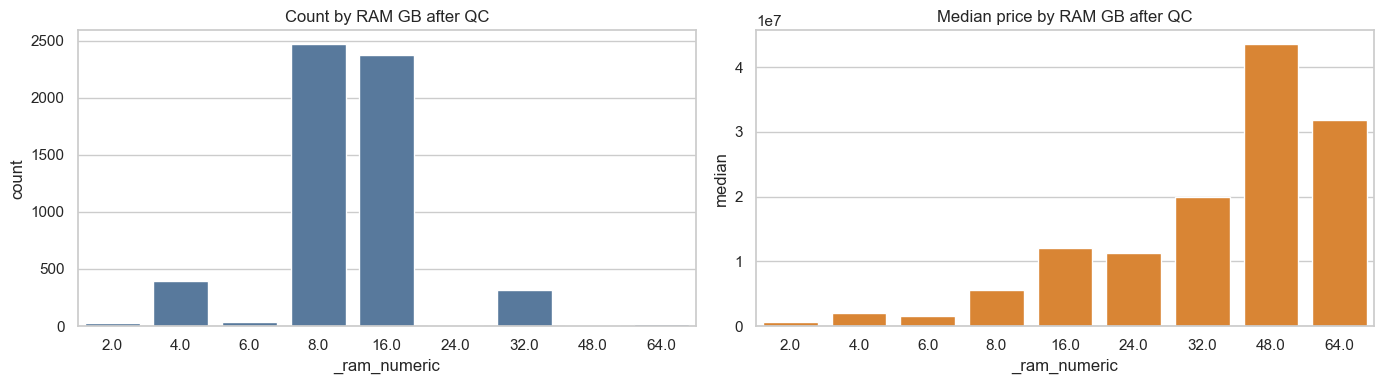

,validation_topic,decision,needs_pipeline_fix
0,RAM suspicious,Suspicious or out-of-range RAM is retained as a row-level flag and converted to NaN in every parsed numeric RAM feature.,False


In [10]:
ram_col = COL["ram"]
ram_original = pd.to_numeric(cleaned[ram_col], errors="coerce")
ram_min, ram_max = 2, 128
valid_ram_levels = set(config.get("valid_ram_levels", [2, 4, 6, 8, 12, 16, 24, 32, 36, 48, 64, 96, 128]))
ram_suspicious_mask = bool_series(cleaned[COL["ram_suspicious"]]) if COL.get("ram_suspicious") else (~ram_original.isin(valid_ram_levels) & ram_original.notna())
ram_outside_range_mask = ram_original.notna() & ((ram_original < ram_min) | (ram_original > ram_max))
ram_invalid_mask = ram_original.notna() & (~ram_original.isin(valid_ram_levels) | ram_outside_range_mask)
ram_nullify_mask = ram_suspicious_mask | ram_outside_range_mask
ram_numeric_feature_cols = [c for c in ["_ram_gb", "_ram_gb_filled", "_title_ram_gb"] if c in cleaned.columns]

# Preserve parser outputs for audit, but prevent suspicious RAM from becoming clean numeric model features.
for c in ram_numeric_feature_cols:
    audit_col = f"{c}_original_before_qc"
    if audit_col not in cleaned.columns:
        cleaned[audit_col] = pd.to_numeric(cleaned[c], errors="coerce")
    cleaned.loc[ram_nullify_mask, c] = np.nan
if "ram_gb_original_before_qc" not in cleaned.columns:
    cleaned["ram_gb_original_before_qc"] = ram_original
cleaned.loc[ram_nullify_mask, ram_col] = np.nan
ram = pd.to_numeric(cleaned[ram_col], errors="coerce")

ram_still_impossible_mask = pd.Series(False, index=cleaned.index)
ram_suspicious_numeric_remaining_mask = pd.Series(False, index=cleaned.index)
for c in ram_numeric_feature_cols:
    c_numeric = pd.to_numeric(cleaned[c], errors="coerce")
    ram_still_impossible_mask |= c_numeric.notna() & ((c_numeric < ram_min) | (c_numeric > ram_max))
    ram_suspicious_numeric_remaining_mask |= ram_suspicious_mask & c_numeric.notna()

ram_summary = pd.DataFrame([{
    "ram_column": ram_col,
    "numeric_ram_columns_qc_applied": ", ".join(ram_numeric_feature_cols),
    "dtype_after_qc": str(cleaned[ram_col].dtype),
    "missing_after_qc": int(ram.isna().sum()),
    "original_min": ram_original.min(),
    "original_max": ram_original.max(),
    "clean_min": ram.min(),
    "clean_max": ram.max(),
    "outside_valid_list_before_qc": int((~ram_original.isin(valid_ram_levels) & ram_original.notna()).sum()),
    "outside_2_128gb_before_qc": int(ram_outside_range_mask.sum()),
    "ram_suspicious_flagged": int(ram_suspicious_mask.sum()),
    "set_to_nan_for_modeling": int(ram_nullify_mask.sum()),
    "impossible_values_remaining_after_qc": int(ram_still_impossible_mask.sum()),
    "suspicious_rows_with_numeric_ram_remaining": int(ram_suspicious_numeric_remaining_mask.sum()),
}])
ram_counts = ram.value_counts(dropna=False).sort_index().rename_axis("ram_gb_after_qc").reset_index(name="count")
price_by_ram = cleaned.assign(_price_numeric=price, _ram_numeric=ram).groupby("_ram_numeric", dropna=False)["_price_numeric"].agg(["count", "median", "mean"]).reset_index()

ram_feature_policy = pd.DataFrame([
    {"column": c, "role": "model_feature", "policy": "Parsed numeric RAM after QC; suspicious/out-of-range values are set to NaN."}
    for c in ram_numeric_feature_cols
] + [
    {"column": f"{c}_original_before_qc", "role": "audit_only", "policy": "Original parsed RAM retained in cleaned_full export for traceability."}
    for c in ram_numeric_feature_cols
] + [
    {"column": COL.get("ram_suspicious"), "role": "model_feature_allowed", "policy": "Non-price-derived QC flag available at prediction time; keep as optional feature."},
])

display(ram_summary)
display(ram_counts)
display(price_by_ram)
display(ram_feature_policy)
show_or_empty(sample_rows(ram_suspicious_mask, [COL["title"], COL["description"], ram_col, "ram_gb_original_before_qc", COL["ram_raw"], target_col, COL["brand"], COL["model"], COL["ram_suspicious"]], 12))

if PLOTTING_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.countplot(data=cleaned.assign(_ram_numeric=ram), x="_ram_numeric", ax=axes[0], color="#4C78A8"); axes[0].set_title("Count by RAM GB after QC")
    sns.barplot(data=price_by_ram.dropna(subset=["_ram_numeric"]), x="_ram_numeric", y="median", ax=axes[1], color="#F58518"); axes[1].set_title("Median price by RAM GB after QC")
    plt.tight_layout(); plt.show()

pd.DataFrame([{"validation_topic": "RAM suspicious", "decision": "Suspicious or out-of-range RAM is retained as a row-level flag and converted to NaN in every parsed numeric RAM feature.", "needs_pipeline_fix": bool(ram_still_impossible_mask.sum() > 0 or ram_suspicious_numeric_remaining_mask.sum() > 0)}])

**Nhận xét sau RAM validation và plot**

Biểu đồ RAM sau QC nên được đọc trên các giá trị numeric đã làm sạch, không phải giá trị parser ban đầu. Các dòng ram_suspicious vẫn được giữ trong dataset, nhưng những numeric RAM parse đáng ngờ như 1GB, 33GB, 129GB hoặc giá trị suy luận không chắc chắn đã được set thành NaN ở các RAM numeric feature.

Đây là quyết định quan trọng cho chất lượng feature: model không bị học nhầm giá trị RAM bất thường như một thông số hợp lệ, nhưng vẫn có thể dùng ram_suspicious như một optional feature vì flag này không phụ thuộc vào target price.

## 7. Storage Validation

Storage được kiểm tra như một numeric spec: missing, phân phối dung lượng, loại ổ cứng, và flag `was_storage_type_imputed`. Các giá trị storage bất khả thi có thể ảnh hưởng mạnh đến model nên được xem là blocking nếu chưa được xử lý/flag rõ ràng.

Flag `was_storage_type_imputed` không phải price-derived, nên có thể là optional feature nếu quy trình prediction cũng có cùng logic imputation.

,storage_column,dtype,missing,min,max,unique_values_top,storage_type_column,storage_type_missing,storage_type_imputed_flagged
0,_storage_gb_filled,float64,434,127.0,1025.0,"[127.0, 128.0, 250.0, 256.0, 320.0, 480.0, 500.0, 512.0, 640.0, 750.0, 1024.0, 1025.0]",storage_type_clean,0,11


,storage_gb,count
0,127.0,478
1,128.0,225
2,250.0,122
3,256.0,2161
4,320.0,20
5,480.0,15
6,500.0,127
7,512.0,1870
8,640.0,4
9,750.0,13


,storage_type,count
0,SSD,5034
1,Unknown,715
2,HDD,117


,_storage_numeric,count,median
0,127.0,478,2800000.0
1,128.0,225,2900000.0
2,250.0,122,3475000.0
3,256.0,2161,6800000.0
4,320.0,20,1250000.0
5,480.0,15,6500000.0
6,500.0,127,3200000.0
7,512.0,1870,12900000.0
8,640.0,4,3850000.0
9,750.0,13,6500000.0


,storage_type_clean,count,median
1,SSD,5034,7900000.0
2,Unknown,714,6445000.0
0,HDD,117,1350000.0


,title,_storage_gb_filled,Ổ cứng,storage_type_clean,_price,was_storage_type_imputed
103,Laptop Dell i7 4600u 4g hdd 500gb,500.0,NaN,HDD,1400000.0,True
594,HP 830G5 bạc i5 7200u/ 8Gb / ssd 128GB bh 3 tháng,128.0,NaN,SSD,3550000.0,True
1923,Surface Laptop 4 i7/1185G7/Ram 8G/SSD 256G Cảm Ứng,NaN,NaN,SSD,11900000.0,True
2942,Macbook M2 PRO 16' Gray Ram 32GB / Ssd 1TB Pin 96%,1024.0,1 TB,SSD,32900000.0,True
2978,"MacBook Pro - Core i5, RAM 8GB, SSD 256GB",256.0,256 GB,SSD,6000000.0,True
3019,Fujitsu Lifebook AH45 i3 Gen 6| RAM 8|SSD 256gb,256.0,256 GB,SSD,3800000.0,True
3287,Dell Latitude E7240 i5-4300U 4GB SSD MSATA,NaN,NaN,SSD,1200000.0,True
3592,"Dell Latitude i5, RAM 16GB, SSD 512GB",512.0,512 GB,SSD,8500000.0,True
4871,Macbook Air 13inch Chip M4 Ram 16Gb SSD 512Gb,256.0,256 GB,SSD,28000000.0,True
5330,Dell Laptop i5 Ram 8GB SSD 128+ HDD 500 GB,500.0,NaN,HDD,1750000.0,True


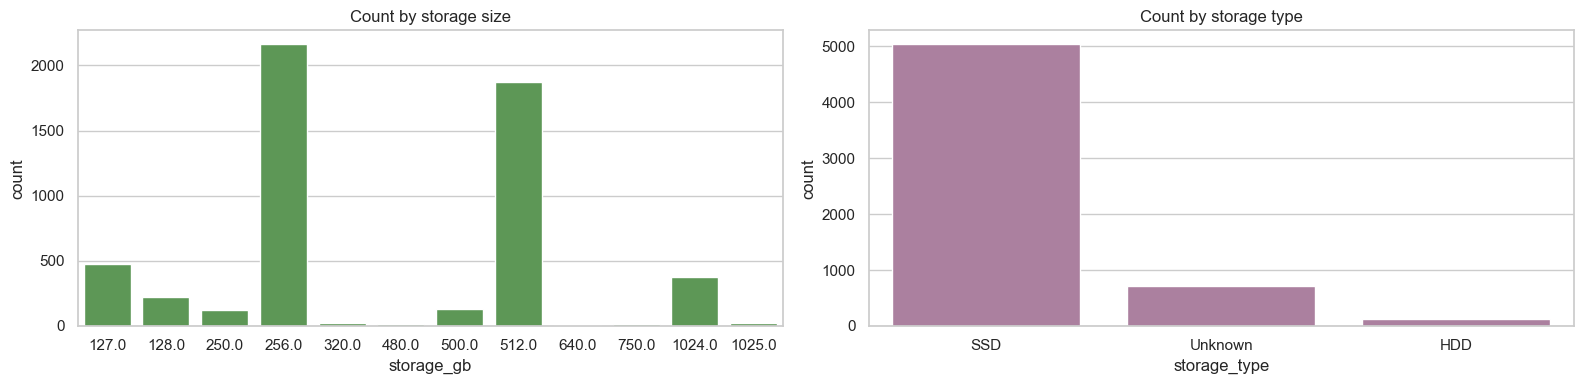

,validation_topic,decision,needs_pipeline_fix
0,Storage conversion and imputation,Keep imputation flag. Review extreme storage sizes before modeling.,False


In [11]:
storage_col = COL["storage"]
storage = pd.to_numeric(cleaned[storage_col], errors="coerce")
storage_type_col = COL["storage_type"]
storage_type_imputed_mask = bool_series(cleaned[COL["storage_type_imputed"]]) if COL.get("storage_type_imputed") else pd.Series(False, index=cleaned.index)

storage_summary = pd.DataFrame([{
    "storage_column": storage_col, "dtype": str(cleaned[storage_col].dtype), "missing": int(storage.isna().sum()),
    "min": storage.min(), "max": storage.max(), "unique_values_top": sorted(storage.dropna().unique().tolist())[:30],
    "storage_type_column": storage_type_col, "storage_type_missing": int(cleaned[storage_type_col].isna().sum()) if storage_type_col else np.nan,
    "storage_type_imputed_flagged": int(storage_type_imputed_mask.sum()),
}])
storage_counts = storage.value_counts(dropna=False).sort_index().rename_axis("storage_gb").reset_index(name="count")
storage_type_counts = cleaned[storage_type_col].value_counts(dropna=False).rename_axis("storage_type").reset_index(name="count") if storage_type_col else pd.DataFrame()
price_by_storage = cleaned.assign(_price_numeric=price, _storage_numeric=storage).groupby("_storage_numeric", dropna=False)["_price_numeric"].agg(["count", "median"]).reset_index()
price_by_storage_type = cleaned.assign(_price_numeric=price).groupby(storage_type_col, dropna=False)["_price_numeric"].agg(["count", "median"]).reset_index().sort_values("count", ascending=False) if storage_type_col else pd.DataFrame()

display(storage_summary)
display(storage_counts)
display(storage_type_counts)
display(price_by_storage)
display(price_by_storage_type)
show_or_empty(sample_rows(storage_type_imputed_mask, [COL["title"], COL["description"], storage_col, COL["storage_raw"], storage_type_col, COL["price"], COL["storage_type_imputed"]], 12))

if PLOTTING_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    sns.barplot(data=storage_counts.head(30), x="storage_gb", y="count", ax=axes[0], color="#54A24B"); axes[0].set_title("Count by storage size")
    sns.barplot(data=storage_type_counts, x="storage_type", y="count", ax=axes[1], color="#B279A2"); axes[1].set_title("Count by storage type")
    plt.tight_layout(); plt.show()

pd.DataFrame([{"validation_topic": "Storage conversion and imputation", "decision": "Keep imputation flag. Review extreme storage sizes before modeling.", "needs_pipeline_fix": bool((storage > 4096).sum() > 0 or (storage <= 0).sum() > 0)}])

**Nhận xét sau storage validation và plot**

Phân phối storage giúp kiểm tra xem parser có tạo ra dung lượng bất thường hay không. Các mức phổ biến như 256GB, 512GB, 1TB thường hợp lý với laptop; giá trị quá lớn hoặc không dương mới là rủi ro blocking.

Flag was_storage_type_imputed xuất hiện ở 11 dòng. Đây là cảnh báo non-blocking: dòng dữ liệu vẫn dùng được, nhưng feature engineering nên cân nhắc giữ flag này để model biết storage type đã được suy luận thay vì đọc trực tiếp từ listing.

## 8. Screen Size Validation

Screen size được kiểm tra theo range laptop hợp lý từ config, mặc định khoảng `8` đến `22` inch. Out-of-range screen size có thể là lỗi parse hoặc dữ liệu không thuộc laptop, nên validation sẽ xem đây là blocking nếu còn giá trị bất khả thi chưa được flag/quarantine.

,screen_column,dtype,missing,min,max,outside_8_22_inch
0,_screen_size_inch_filled,float64,998,8.9,21.0,0


,screen_size_inch,count
0,8.9,2
1,10.0,19
2,12.0,212
3,13.0,6
4,13.3,2
5,14.0,2391
6,15.0,3
7,15.6,2
8,16.0,2122
9,17.0,1


No rows found.


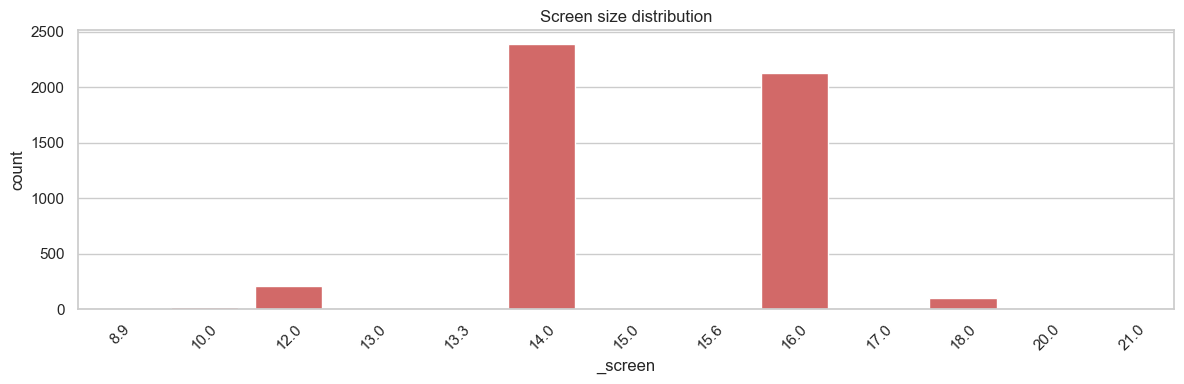

,validation_topic,decision,needs_pipeline_fix
0,Screen size range,8-22 inch is reasonable. Out-of-range values should be reviewed/flagged.,False


In [12]:
screen_col = COL["screen"]
screen = pd.to_numeric(cleaned[screen_col], errors="coerce")
screen_min = config.get("screen_min", 8)
screen_max = config.get("screen_max", 22)
screen_out_of_range = screen.notna() & ((screen < screen_min) | (screen > screen_max))

screen_summary = pd.DataFrame([{
    "screen_column": screen_col, "dtype": str(cleaned[screen_col].dtype), "missing": int(screen.isna().sum()),
    "min": screen.min(), "max": screen.max(), f"outside_{screen_min}_{screen_max}_inch": int(screen_out_of_range.sum()),
}])
screen_counts = screen.round(1).value_counts(dropna=False).sort_index().rename_axis("screen_size_inch").reset_index(name="count")
display(screen_summary)
display(screen_counts)
show_or_empty(sample_rows(screen_out_of_range, [COL["title"], screen_col, "Kích cỡ màn hình", COL["price"], COL["brand"], COL["model"]], 12))

if PLOTTING_AVAILABLE:
    plt.figure(figsize=(12, 4))
    sns.countplot(data=cleaned.assign(_screen=screen.round(1)), x="_screen", color="#E45756")
    plt.title("Screen size distribution"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

pd.DataFrame([{"validation_topic": "Screen size range", "decision": f"{screen_min}-{screen_max} inch is reasonable. Out-of-range values should be reviewed/flagged.", "needs_pipeline_fix": bool(screen_out_of_range.sum() > 0)}])

**Nhận xét sau screen size validation và plot**

Screen size được kiểm tra theo range laptop hợp lý 8-22 inch. Nếu plot có các điểm nằm ngoài range này, đó thường là lỗi parse hoặc listing không đúng đối tượng. Trong kết quả hiện tại, blocking check cho screen size pass, nên screen numeric feature có thể chuyển tiếp sang feature engineering.

Với screen size, không nên drop row chỉ vì thiếu giá trị; missing screen có thể được xử lý bằng imputation hoặc missing indicator.

## 9. Brand / Model Validation

Brand/model là categorical feature có ảnh hưởng lớn đến giá, nhưng cũng thường có long-tail category và giá trị không parse được. Section này kiểm tra phân phối brand/model, các alias phổ biến, và số dòng model được parse thành `Dòng Khác`.

`Dòng Khác` không làm fail notebook vì đây là thông tin không hoàn hảo nhưng vẫn có thể modeling được. Tuy nhiên nó là non-blocking warning để bước feature engineering cân nhắc grouping, top-N category, hoặc encoder phù hợp.

In [13]:
brand_col = COL["brand"]
model_col = COL["model"]
brand_distribution = cleaned[brand_col].fillna("Unknown").value_counts().rename_axis("brand").reset_index(name="count")
brand_distribution["pct"] = brand_distribution["count"] / len(cleaned)
top_models = cleaned[model_col].fillna("Unknown").value_counts().head(40).rename_axis("model").reset_index(name="count")
brand_unknown_mask = cleaned[brand_col].isna() | cleaned[brand_col].astype(str).str.lower().isin(["unknown", "other", "khác", "hang khac", "hãng khác"])
model_unknown_mask = cleaned[model_col].isna() | cleaned[model_col].astype(str).str.lower().isin(["unknown", "other", "dòng khác", "dong khac", "khác"])

patterns = {
    "Apple/MacBook": ["apple", "macbook"],
    "Dell Latitude": ["dell", "latitude"],
    "Lenovo ThinkPad": ["lenovo", "thinkpad"],
    "HP EliteBook": ["hp", "elitebook"],
    "ASUS ROG/TUF": ["asus", "rog|tuf"],
    "Acer Nitro": ["acer", "nitro"],
}
text_probe = cleaned[[c for c in [COL["title"], brand_col, model_col] if c]].astype(str).agg(" ".join, axis=1).str.lower()
probe_rows = []
for label, tokens in patterns.items():
    mask = pd.Series(True, index=cleaned.index)
    for token in tokens:
        mask &= text_probe.str.contains(token, regex=True, na=False)
    probe_rows.append({"pattern": label, "matched_rows": int(mask.sum()), "top_brand_values": cleaned.loc[mask, brand_col].value_counts().head(5).to_dict(), "top_model_values": cleaned.loc[mask, model_col].value_counts().head(5).to_dict()})

alias_rows = []
for brand, aliases in config.get("brand_aliases", {}).items():
    pattern = "|".join(re.escape(a) for a in aliases)
    text_has_alias = cleaned[COL["title"]].astype(str).str.contains(pattern, case=False, regex=True, na=False) if COL["title"] else pd.Series(False, index=cleaned.index)
    normalized_other = cleaned[brand_col].astype(str).str.lower().ne(str(brand).lower())
    alias_rows.append({"brand": brand, "alias_hits_not_normalized_to_brand": int((text_has_alias & normalized_other).sum())})

display(brand_distribution)
display(top_models)
display(pd.DataFrame(probe_rows))
show_or_empty(sample_rows(brand_unknown_mask, [COL["title"], brand_col, COL["brand_raw"], model_col, COL["price"]], 12))
show_or_empty(sample_rows(model_unknown_mask, [COL["title"], brand_col, model_col, COL["model_raw"], COL["price"]], 12))
display(pd.DataFrame(alias_rows).sort_values("alias_hits_not_normalized_to_brand", ascending=False))

,brand,count,pct
0,Dell,1837,0.313161
1,Apple,918,0.156495
2,Lenovo,800,0.136379
3,HP,704,0.120014
4,ASUS,625,0.106546
5,Acer,365,0.062223
6,MSI,192,0.032731
7,Microsoft,178,0.030344
8,Hãng khác,91,0.015513
9,Sony,37,0.006308


,model,count
0,Dòng Khác,890
1,Latitude,467
2,MacBook Pro,324
3,Precision,195
4,MacBook Air,183
5,Inspiron,166
6,ThinkPad,109
7,Elitebook,96
8,ProBook,90
9,Nitro 5,89


,pattern,matched_rows,top_brand_values,top_model_values
0,Apple/MacBook,913,{'Apple': 913},"{'MacBook Pro': 324, 'MacBook Air': 183, 'MacBook Pro M1': 86, 'MacBook Air M1': 82, 'Macbook air m4': 51}"
1,Dell Latitude,829,"{'Dell': 827, 'Apple': 1, 'Hãng khác': 1}","{'Latitude': 467, 'Dòng Khác': 147, 'Latitude 14 7000': 58, 'Latitude E Series': 55, 'Latitude 14 5000': 28}"
2,Lenovo ThinkPad,424,"{'Lenovo': 422, 'HP': 2}","{'ThinkPad': 109, 'ThinkPad X1 Carbon': 65, 'Dòng Khác': 61, 'ThinkPad X13': 26, 'ThinkPad T14 Gen 3': 21}"
3,HP EliteBook,164,"{'HP': 163, 'Hãng khác': 1}","{'Elitebook': 96, 'Elitebook 800': 38, 'Elitebook x360': 8, 'EliteBook 8': 5, 'Elitebook 600': 4}"
4,ASUS ROG/TUF,208,{'ASUS': 208},"{'TUF Gaming F15': 42, 'TUF Gaming': 42, 'ROG Strix': 30, 'TUF Gaming A15': 18, 'ROG Zephyrus G14': 16}"
5,Acer Nitro,126,{'Acer': 126},"{'Nitro 5': 89, 'Nitro v15': 26, 'Aspire Nitro': 3, 'Aspire Nitro V15': 3, 'Dòng Khác': 2}"


,title,brand_clean,Hãng,model_clean,_price
2305,NEC Core i5 10210y 8/128 (lỗi nhỏ),Hãng khác,Hãng khác,Dòng Khác,2800000.0
1262,Laptop Nokia Booklet Intel Atom (giá 600k),Hãng khác,Hãng khác,Dòng Khác,600000.0
3613,IBM X60S Đen Đã qua sử dụng,Hãng khác,Hãng khác,Dòng Khác,200000.0
5720,"Laptop i5-1135G7_16G_512G_15.6"" VP Học tập Mượt🎁",Hãng khác,Hãng khác,Dòng Khác,4990000.0
59,Laptop Fujitsu U9311 i5/8gb/256GB,Hãng khác,Hãng khác,Dòng Khác,3900000.0
1372,"Laptop Gateway i5-1035G1 16G 256G 14"" FHD BH 6 th",Hãng khác,Hãng khác,Dòng Khác,5900000.0
2244,Laptop Gemibook Pro 14 inch 8GB/256GB,Hãng khác,Hãng khác,Dòng Khác,5000000.0
4394,Compaq Presario CQ42 Đen,Hãng khác,Hãng khác,Dòng Khác,700000.0
415,NEC VersaPro VH1 i5 Ram 8,Hãng khác,Hãng khác,Dòng Khác,2500000.0
2974,Laptop TU45C i7-1195G7 | RAM 8GB | SSD256GB,Hãng khác,Hãng khác,Dòng Khác,8000000.0


,title,brand_clean,model_clean,Dòng máy,_price
445,laptop i3 6130u 240 gb sx 2018 đẹp nguyên zin,Panasonic,Dòng Khác,Dòng Khác,1390000.0
3043,Dell Latitude 5530 i5-1245U 8GB/256GB,Dell,Dòng Khác,Dòng Khác,7900000.0
1372,"Laptop Gateway i5-1035G1 16G 256G 14"" FHD BH 6 th",Hãng khác,Dòng Khác,Dòng Khác,5900000.0
1569,Lenovo G50-70 Hỏng nguồn,Lenovo,Dòng Khác,Dòng Khác,500000.0
254,Laptop I7 giá xác,LG,Dòng Khác,Dòng Khác,400000.0
5505,Dell 3535 Ryzen 7 15.6 inch 16GB/512GB,Dell,Dòng Khác,Dòng Khác,12900000.0
3217,Acer Aspire ES-576 i5-8250U 16GB/120GB,Acer,Dòng Khác,Dòng Khác,2500000.0
700,Lenovo LOQ E 15IAX9E i5-12450H/16/512GB RTX3050,Lenovo,Dòng Khác,Dòng Khác,15500000.0
459,Dell Latitude 5410 i7 14 inch 8GB/256GB,Dell,Dòng Khác,Dòng Khác,6500000.0
551,Asus E502S Intel N3050 15 inch 2GB Đã sử dụng,ASUS,Dòng Khác,Dòng Khác,700000.0


,brand,alias_hits_not_normalized_to_brand
2,HP,12
1,Dell,8
3,Lenovo,5
5,MSI,4
0,ASUS,3
6,Apple,2
15,Toshiba,1
14,Sony,1
9,Gigabyte,1
7,Microsoft,1


**Nhận xét sau brand/model validation**

Brand/model là nhóm feature có sức giải thích cao nhưng cũng dễ bị long-tail. Kết quả hiện tại có 904 dòng model được parse thành Dòng Khác, đây là warning lớn nhất theo số dòng ảnh hưởng.

Warning này không chặn modeling vì model vẫn có thể học từ brand, specs, condition và các feature khác. Tuy nhiên ở bước feature engineering, nên group rare model, dùng top-N category, hoặc encoder có regularization để tránh overfit các model hiếm.

## 10. GPU / CPU Validation

CPU/GPU parsing thường không đầy đủ vì listing có thể thiếu thông tin hoặc ghi trong title/description theo nhiều kiểu. Section này kiểm tra distribution của CPU/GPU tier và flag `potential_dedicated_gpu`.

`potential_dedicated_gpu` là non-price-derived QC flag. Nó có thể được dùng làm optional feature nếu logic tạo flag chỉ dựa vào thông tin listing có sẵn tại prediction time.

In [14]:
potential_gpu_mask = bool_series(cleaned[COL["potential_dedicated_gpu"]]) if COL.get("potential_dedicated_gpu") else pd.Series(False, index=cleaned.index)
for label, col in [("cpu_brand", COL["cpu_brand"]), ("cpu_tier", COL["cpu_tier"]), ("gpu_tier", COL["gpu_tier"]), ("cpu_raw", COL["cpu"]), ("gpu_raw", COL["gpu"])]:
    if col:
        print(label)
        display(cleaned[col].fillna("Missing").value_counts().head(30).rename_axis(label).reset_index(name="count"))

cpu_gpu_missing = pd.DataFrame([
    {"field": "CPU", "column": COL["cpu"], "missing_pct": cleaned[COL["cpu"]].isna().mean() if COL["cpu"] else np.nan},
    {"field": "GPU", "column": COL["gpu"], "missing_pct": cleaned[COL["gpu"]].isna().mean() if COL["gpu"] else np.nan},
    {"field": "CPU brand", "column": COL["cpu_brand"], "missing_pct": cleaned[COL["cpu_brand"]].isna().mean() if COL["cpu_brand"] else np.nan},
    {"field": "GPU tier", "column": COL["gpu_tier"], "missing_pct": cleaned[COL["gpu_tier"]].isna().mean() if COL["gpu_tier"] else np.nan},
])
display(cpu_gpu_missing)
show_or_empty(sample_rows(potential_gpu_mask, [COL["title"], COL["description"], COL["gpu"], COL["gpu_tier"], COL["price"], COL["brand"], COL["model"], COL["potential_dedicated_gpu"]], 12))
pd.DataFrame([{"validation_topic": "CPU/GPU parsing", "decision": "Use parsed CPU/GPU as helpful but incomplete features. Let feature engineering handle missing and text-derived signals.", "needs_pipeline_fix": False}])

cpu_brand


,cpu_brand,count
0,Intel,4663
1,AMD,472
2,Apple,425
3,Unknown,306


cpu_tier


,cpu_tier,count
0,Mid,2831
1,Upper-mid,1892
2,Entry,388
3,Other,258
4,Missing,218
5,High,204
6,Low,75


gpu_tier


...

gpu_raw


,gpu_raw,count
0,Onboard,2565
1,NVIDIA,1458
2,Missing,1421
3,Khác,247
4,AMD,175


,field,column,missing_pct
0,CPU,Bộ vi xử lý,0.042448
1,GPU,Card màn hình,0.242243
2,CPU brand,cpu_brand,0.000000
3,GPU tier,gpu_tier,0.000000


,title,Card màn hình,gpu_tier,_price,brand_clean,model_clean,potential_dedicated_gpu
3192,Dell G3 3579 i5 8300H 8GB/256GB💻,NaN,Missing,4000000.0,Dell,Gaming G3,True
3026,MSI Modern 14 i3 8GB/222GB Đen,NaN,Missing,5000000.0,MSI,Modern 14,True
2829,MSI GL63 i7-8750H 8GB ssd 128GB 500HDD GTX 1050,NaN,Missing,4800000.0,MSI,GL Series,True
3730,MacbookPro 2019 i9/32GB/4TB Vga 4Gb có giao lưu,NaN,Missing,15900000.0,Apple,MacBook Pro,True
1010,Acer Nitro 5 i5 9300h 16GB Đã dùng,NaN,Missing,5000000.0,Acer,Nitro 5,True
2241,Lenovo Thinkbook 14 G16 16GB/512GB,NaN,Missing,9000000.0,Lenovo,Thinkbook 14 gen 6,True
4999,Thanh lý Laptop Gaming Msi đep zin,NaN,Missing,8200000.0,MSI,Gaming Thin GF,True
3995,Laptop gaming Acer Intel Core i5 8GB,NaN,Missing,2950000.0,Acer,Aspire 5,True
5403,Asus Rog Strix G531GD i5-9300H 8GB/500GB,NaN,Missing,6000000.0,ASUS,ROG Strix,True
1458,ASUS TUF Gaming FX505GD i5-8300H 16GB,NaN,Missing,6850000.0,ASUS,TUF Gaming,True


,validation_topic,decision,needs_pipeline_fix
0,CPU/GPU parsing,Use parsed CPU/GPU as helpful but incomplete features. Let feature engineering handle missing and text-derived signals.,False


**Nhận xét sau CPU/GPU validation**

CPU/GPU parser cung cấp tín hiệu có ích nhưng không nên kỳ vọng đầy đủ tuyệt đối vì nhiều listing ghi spec trong title/description không chuẩn. Flag potential_dedicated_gpu có 40 dòng, nên được xem như non-blocking warning.

Khác với price-derived flags, potential_dedicated_gpu có thể là optional feature nếu ở production/prediction ta vẫn tạo được flag này từ thông tin listing đầu vào.

## 11. Condition / Repair Mismatch Validation

Section này kiểm tra mâu thuẫn giữa tình trạng máy và tín hiệu sửa chữa/hư hỏng trong title/description. Ví dụ listing ghi tình trạng tốt nhưng text lại có keyword như lỗi, hỏng, thay màn, chai pin.

Notebook không drop các dòng này vì chúng có thể phản ánh đúng thị trường máy cũ. Thay vào đó `repair_mismatch` được giữ làm QC flag và optional feature không price-derived.

In [15]:
condition_col = COL["condition"]
repair_mismatch_mask = bool_series(cleaned[COL["repair_mismatch"]]) if COL.get("repair_mismatch") else pd.Series(False, index=cleaned.index)
condition_distribution = cleaned[condition_col].fillna("Missing").value_counts().rename_axis("condition").reset_index(name="count") if condition_col else pd.DataFrame()
if len(condition_distribution):
    condition_distribution["pct"] = condition_distribution["count"] / len(cleaned)

repair_keywords = r"sửa|loi|lỗi|hong|hỏng|can|cấn|mop|móp|be|bể|vo|vỡ|thay màn|thay man|thay pin|chai pin|bể màn|vo man|vỡ màn"
text_cols = [c for c in [COL["title"], COL["description"]] if c]
combined_text = cleaned[text_cols].astype(str).agg(" ".join, axis=1).str.lower() if text_cols else pd.Series("", index=cleaned.index)
repair_signal_mask = combined_text.str.contains(repair_keywords, regex=True, na=False)
condition_repair_cross = pd.crosstab(cleaned[condition_col].fillna("Missing") if condition_col else "Missing", repair_signal_mask, margins=True).rename(columns={False: "no_repair_keyword", True: "has_repair_keyword"})

display(condition_distribution)
display(condition_repair_cross)
show_or_empty(sample_rows(repair_mismatch_mask, [COL["title"], COL["description"], condition_col, COL["price"], COL["brand"], COL["model"], COL["repair_mismatch"]], 12))
pd.DataFrame([{"validation_topic": "Repair mismatch", "decision": "Keep as warning flag, not automatic exclusion. Create has_damage_or_repair_signal in feature engineering.", "repair_keyword_rows": int(repair_signal_mask.sum()), "repair_mismatch_rows": int(repair_mismatch_mask.sum())}])

,condition,count,pct
0,Đã sử dụng (chưa sửa chữa),5594,0.953631
1,Mới,182,0.031026
2,Đã sử dụng (qua sửa chữa),90,0.015343


col_0,no_repair_keyword,has_repair_keyword,All
condition_clean,,,
Mới,152,30,182
Đã sử dụng (chưa sửa chữa),4740,854,5594
Đã sử dụng (qua sửa chữa),61,29,90
All,4953,913,5866


,title,condition_clean,_price,brand_clean,model_clean,repair_mismatch
1268,Bán xác Laptop Asus u36j Đen Đã sử dụng,Đã sử dụng (chưa sửa chữa),500000.0,ASUS,Adolbook 13,True
2383,xác Lenovo Yoga Pro 2 Core i7 Gen 4 Ram 8GB,Đã sử dụng (chưa sửa chữa),600000.0,Lenovo,Yoga 2 Pro,True
1313,"pin new, ngoại hình đẹp, chưa sửa chữa, bao test",Đã sử dụng (chưa sửa chữa),6800000.0,Apple,MacBook,True
3963,"Bán Surface Pro 7 Plus i5 8GB/256GB, vỡ màn hình",Đã sử dụng (chưa sửa chữa),5300000.0,Microsoft,Surface Pro 7+,True
254,Laptop I7 giá xác,Đã sử dụng (chưa sửa chữa),400000.0,LG,Dòng Khác,True
1700,e bán xác,Đã sử dụng (chưa sửa chữa),600000.0,Hãng khác,Dòng Khác,True
3283,[XÁC ZIN ÚC] MacBook Air 2013 11-inch,Đã sử dụng (chưa sửa chữa),1200000.0,Apple,MacBook Air,True
3470,Alienware gaming 15 R2 i7 6700HQ GTX 970M 4K Lỗi,Đã sử dụng (chưa sửa chữa),2000000.0,Dell,Alienware 15,True
2305,NEC Core i5 10210y 8/128 (lỗi nhỏ),Đã sử dụng (chưa sửa chữa),2800000.0,Hãng khác,Dòng Khác,True
4305,Xác Apple MacBook Air M2 13inch ko Main mới 99%,Đã sử dụng (chưa sửa chữa),5390000.0,Apple,MacBook Air M2,True


,validation_topic,decision,repair_keyword_rows,repair_mismatch_rows
0,Repair mismatch,"Keep as warning flag, not automatic exclusion. Create has_damage_or_repair_signal in feature engineering.",913,27


**Nhận xét sau condition/repair mismatch validation**

repair_mismatch có 27 dòng, thể hiện trường hợp tình trạng máy và keyword sửa chữa/hư hỏng trong text chưa hoàn toàn khớp nhau. Đây là tín hiệu quan trọng với laptop cũ nhưng không phải lý do drop row.

Cách dùng hợp lý là giữ flag này cho QC và cân nhắc dùng làm feature không price-derived. Nếu model dự đoán giá listing thực tế, thông tin về sửa chữa/hư hỏng có thể là tín hiệu có thật tại prediction time.

## 12. Location Validation

Location/origin có thể ảnh hưởng đến giá do khác biệt thị trường, chi phí giao dịch, hoặc cách người bán đăng tin. Section này kiểm tra phân phối location và các nhóm hiếm.

Low-count location không phải lỗi dữ liệu. Vấn đề này nên được xử lý ở feature engineering bằng grouping hoặc encoder có regularization.

In [16]:
location_col = COL["location"]
if location_col:
    location_counts = cleaned[location_col].fillna("Missing").value_counts().rename_axis("location").reset_index(name="count")
    location_counts["pct"] = location_counts["count"] / len(cleaned)
    rare_locations = location_counts[location_counts["count"] < config.get("rare_count_threshold", 30)].copy()
    price_by_location = cleaned.assign(_price_numeric=price).groupby(location_col, dropna=False)["_price_numeric"].agg(["count", "median"]).reset_index().sort_values("count", ascending=False)
else:
    location_counts = rare_locations = price_by_location = pd.DataFrame()

print(f"Location column used: {location_col}")
display(location_counts.head(30))
display(rare_locations.head(30))
display(price_by_location.query("count >= 30").head(30) if len(price_by_location) else price_by_location)

Location column used: origin_clean


,location,count,pct
0,Unknown,3536,0.602796
1,Mỹ,1101,0.187692
2,Việt Nam,556,0.094783
3,Nhật Bản,388,0.066144
4,Other,114,0.019434
5,Trung Quốc,94,0.016025
6,Đài Loan,61,0.010399
7,Hàn Quốc,13,0.002216
8,Thái Lan,2,0.000341
9,Đức,1,0.000170


,location,count,pct
7,Hàn Quốc,13,0.002216
8,Thái Lan,2,0.000341
9,Đức,1,0.000170


,origin_clean,count,median
6,Unknown,3535,6899999.0
1,Mỹ,1101,10000000.0
7,Việt Nam,556,10900000.0
2,Nhật Bản,388,5500000.0
3,Other,114,6500000.0
5,Trung Quốc,94,9695000.0
8,Đài Loan,61,17900000.0


**Nhận xét sau location validation**

Location/origin có thể phản ánh khác biệt thị trường hoặc cách người bán đăng tin, nhưng các nhóm ít dòng sẽ không ổn định nếu one-hot trực tiếp. Bảng rare location là gợi ý cho bước feature engineering, không phải danh sách dòng cần loại bỏ.

Nếu dùng location trong model, nên group các location hiếm hoặc dùng encoder có regularization để giảm nhiễu.

## 13. Low-count Categories / Rare Groups

Section này tìm các category hoặc tổ hợp feature có quá ít quan sát. Rare group không làm fail validation, nhưng có thể gây overfitting hoặc encoding không ổn định.

Kết quả ở đây là gợi ý cho notebook feature engineering: group rare brand/model/location, tránh one-hot quá rộng, và dùng numeric RAM/storage trực tiếp thay vì tạo combo category quá thưa.

In [17]:
rare_threshold = config.get("rare_count_threshold", 30)
def rare_table(col, label):
    if not col:
        return pd.DataFrame()
    vc = cleaned[col].fillna("Missing").value_counts().rename_axis(label).reset_index(name="count")
    vc["pct"] = vc["count"] / len(cleaned)
    return vc[vc["count"] < rare_threshold].sort_values("count")

rare_brand = rare_table(COL["brand"], "brand")
rare_model = rare_table(COL["model"], "model")
rare_location = rare_table(location_col, "location") if location_col else pd.DataFrame()
rare_ram_storage_combo = cleaned.assign(_ram=ram, _storage=storage).groupby(["_ram", "_storage"], dropna=False).size().reset_index(name="count").query("count < @rare_threshold").sort_values("count")
rare_price_bins = pd.cut(price, bins=bins, labels=labels, include_lowest=True).value_counts(dropna=False).rename_axis("price_bin").reset_index(name="count").query("count < @rare_threshold")

display(rare_brand)
display(rare_model.head(50))
display(rare_ram_storage_combo.head(50))
display(rare_location.head(50))
display(rare_price_bins)
display(pd.DataFrame([
    {"group": "brand", "decision": "Group rare brands to Other during feature engineering unless business meaning is clear.", "rare_count": len(rare_brand)},
    {"group": "model", "decision": "Use top-N/grouped model or target encoding; raw model is long-tail.", "rare_count": len(rare_model)},
    {"group": "RAM/storage combo", "decision": "Keep numeric RAM/storage; use combo only with enough support or regularization.", "rare_count": len(rare_ram_storage_combo)},
    {"group": "location", "decision": "Group rare location/origin categories before categorical encoding.", "rare_count": len(rare_location)},
]))

,brand,count,pct
18,Honor,1,0.000170
17,LG,4,0.000682
16,Xiaomi,7,0.001193
15,Huawei,9,0.001534
13,Gigabyte,15,0.002557
14,Razer,15,0.002557
12,Samsung,16,0.002728
11,Panasonic,19,0.003239


,model,count,pct
457,Nitro 17,1,0.00017
356,Pro 13 Plus,1,0.00017
357,Yoga 700,1,0.00017
358,Pavilion 13,1,0.00017
359,ThinkPad Yoga 260,1,0.00017
360,Essential,1,0.00017
361,E-Series,1,0.00017
362,ThinkPad L13 Yoga Gen 2,1,0.00017
363,XPS 13 7000,1,0.00017
364,Series 3,1,0.00017


,_ram,_storage,count
74,NaN,1025.0,1
63,48.0,320.0,1
18,6.0,128.0,1
14,4.0,750.0,1
13,4.0,640.0,1
20,6.0,256.0,1
55,24.0,NaN,1
71,NaN,500.0,1
52,24.0,500.0,1
3,2.0,480.0,1


,location,count,pct
9,Đức,1,0.000170
8,Thái Lan,2,0.000341
7,Hàn Quốc,13,0.002216


,price_bin,count
4,NaN,1


,group,decision,rare_count
0,brand,Group rare brands to Other during feature engineering unless business meaning is clear.,8
1,model,Use top-N/grouped model or target encoding; raw model is long-tail.,427
2,RAM/storage combo,Keep numeric RAM/storage; use combo only with enough support or regularization.,57
3,location,Group rare location/origin categories before categorical encoding.,3


**Nhận xét sau rare group validation**

Các bảng rare brand/model/location và RAM-storage combo cho thấy rủi ro sparsity. Rare category không phải lỗi dữ liệu, nhưng có thể làm model ghi nhớ những nhóm rất nhỏ thay vì học pattern tổng quát.

Ở bước tiếp theo, nên ưu tiên numeric specs như RAM/storage/screen, group rare categorical values, và tránh tạo feature combo thưa nếu không có đủ dữ liệu hoặc regularization.

## 14. Modeling-Safe Feature List

Đây là section quan trọng nhất trước modeling. Notebook tạo rõ bốn nhóm cột:

- `target_col`: `_price`, chỉ dùng làm target.
- `leakage_cols`: target, raw price, và các cột price-derived. Nhóm này bị loại khỏi feature list.
- `metadata_cols`: URL, title, description, raw/source columns, audit columns. Nhóm này phục vụ traceability/sample review, không dùng trực tiếp trong tabular baseline.
- `feature_cols`: các cột được phép đưa vào modeling-ready artifact.

Notebook có assertion để đảm bảo `_price` và mọi leakage column không nằm trong `feature_cols`. Nếu có leakage, notebook sẽ fail thay vì lặng lẽ xuất dataset sai.

In [18]:
dropped_expected = set(config.get("drop_columns", []))
still_present_dropped = [c for c in dropped_expected if c in cleaned.columns]

price_derived_cols = [c for c in [COL.get("raw_price"), COL.get("price_outlier"), COL.get("new_low_price"), "price_segment", "is_price_missing"] if c in cleaned.columns]
leakage_cols = sorted(set(base_leakage_cols + price_derived_cols + [c for c in cleaned.columns if c.lower() in {"raw_price"}]))
leakage_cols = [c for c in leakage_cols if c in cleaned.columns]

raw_source_cols = [
    "Hãng", "Dòng máy", "Tình trạng", "Chính sách bảo hành", "Kích cỡ màn hình",
    "Bộ vi xử lý", "RAM", "Card màn hình", "Ổ cứng", "Xuất xứ", "Loại ổ cứng",
]
metadata_cols = sorted(set([
    c for c in [COL.get("url"), COL.get("listing_id"), COL.get("title"), COL.get("description"), "ram_gb_original_before_qc"] if c in cleaned.columns
] + [
    c for c in cleaned.columns
    if any(tok in c.lower() for tok in ["raw", "from_title", "original_before_qc"])
] + [
    c for c in raw_source_cols if c in cleaned.columns
]))

qc_feature_policy = pd.DataFrame([
    {"column": COL.get("price_outlier"), "source": "price-derived", "modeling_role": "QC-only", "allowed_as_feature": False},
    {"column": COL.get("new_low_price"), "source": "price-derived", "modeling_role": "QC-only", "allowed_as_feature": False},
    {"column": "price_segment" if "price_segment" in cleaned.columns else None, "source": "price-derived", "modeling_role": "QC-only", "allowed_as_feature": False},
    {"column": "is_price_missing" if "is_price_missing" in cleaned.columns else None, "source": "price-derived", "modeling_role": "QC-only", "allowed_as_feature": False},
    {"column": COL.get("repair_mismatch"), "source": "condition/text-derived", "modeling_role": "optional feature", "allowed_as_feature": True},
    {"column": COL.get("potential_dedicated_gpu"), "source": "GPU/text-derived", "modeling_role": "optional feature", "allowed_as_feature": True},
    {"column": COL.get("storage_type_imputed"), "source": "imputation-derived", "modeling_role": "optional feature", "allowed_as_feature": True},
    {"column": COL.get("ram_suspicious"), "source": "RAM parser QC", "modeling_role": "optional feature", "allowed_as_feature": True},
]).dropna(subset=["column"])

exclude_from_features = sorted(set(leakage_cols + metadata_cols + list(dropped_expected & set(cleaned.columns))))
feature_cols = [c for c in cleaned.columns if c not in exclude_from_features]

assert target_col not in feature_cols, f"Target leakage detected: {target_col} appears in feature_cols."
leaked_feature_cols = sorted(set(leakage_cols) & set(feature_cols))
assert not leaked_feature_cols, f"Leakage columns present in feature_cols: {leaked_feature_cols}"

quarantine = cleaned.loc[missing_target_mask].copy()
if len(quarantine):
    quarantine.insert(0, "quarantine_reason", f"missing_target_{target_col}")
modeling_ready = cleaned.loc[~missing_target_mask].copy()
modeling_ready_export = modeling_ready[feature_cols + [target_col]].copy()
assert modeling_ready[target_col].isna().sum() == 0, f"Modeling-ready data still has missing {target_col}."
assert target_col in modeling_ready_export.columns and target_col not in feature_cols

modeling_column_summary = pd.DataFrame([
    {"column_group": "target_col", "count": 1, "columns": target_col},
    {"column_group": "feature_cols", "count": len(feature_cols), "columns": ", ".join(feature_cols)},
    {"column_group": "leakage_cols_excluded", "count": len(leakage_cols), "columns": ", ".join(leakage_cols)},
    {"column_group": "metadata_cols_excluded", "count": len(metadata_cols), "columns": ", ".join(metadata_cols)},
])

print(f"Feature columns: {len(feature_cols)}")
print(f"Target column: {target_col}")
print(f"Leakage columns excluded: {leakage_cols}")
display(qc_feature_policy)
display(modeling_column_summary)
display(pd.DataFrame({"feature_col": feature_cols}))
display(pd.DataFrame({"metadata_col": metadata_cols}))
display(pd.DataFrame({"leakage_col_excluded": leakage_cols}))

Feature columns: 39
Target column: _price
Leakage columns excluded: ['_price', 'is_price_missing', 'is_price_outlier', 'new_low_price', 'price', 'price_segment']


,column,source,modeling_role,allowed_as_feature
0,is_price_outlier,price-derived,QC-only,False
1,new_low_price,price-derived,QC-only,False
2,price_segment,price-derived,QC-only,False
3,is_price_missing,price-derived,QC-only,False
4,repair_mismatch,condition/text-derived,optional feature,True
5,potential_dedicated_gpu,GPU/text-derived,optional feature,True
6,was_storage_type_imputed,imputation-derived,optional feature,True
7,ram_suspicious,RAM parser QC,optional feature,True


,column_group,count,columns
0,target_col,1,_price
1,feature_cols,39,"origin_clean, origin_missing_or_unknown, brand_clean, brand_mismatch_title, model_clean, model_recovered, _ram_gb, _storage_gb, _screen_..."
2,leakage_cols_excluded,6,"_price, is_price_missing, is_price_outlier, new_low_price, price, price_segment"
3,metadata_cols_excluded,19,"Bộ vi xử lý, Card màn hình, Chính sách bảo hành, Dòng máy, Hãng, Kích cỡ màn hình, Loại ổ cứng, RAM, Tình trạng, Xuất xứ, _ram_gb_filled..."


,feature_col
0,origin_clean
1,origin_missing_or_unknown
2,brand_clean
3,brand_mismatch_title
4,model_clean
5,model_recovered
6,_ram_gb
7,_storage_gb
8,_screen_size_inch
9,_title_ram_gb


,metadata_col
0,Bộ vi xử lý
1,Card màn hình
2,Chính sách bảo hành
3,Dòng máy
4,Hãng
5,Kích cỡ màn hình
6,Loại ổ cứng
7,RAM
8,Tình trạng
9,Xuất xứ


,leakage_col_excluded
0,_price
1,is_price_missing
2,is_price_outlier
3,new_low_price
4,price
5,price_segment


**Nhận xét sau modeling-safe feature list**

Feature list cuối cùng có 39 cột và đã loại toàn bộ leakage columns: _price, price, price_segment, is_price_outlier, new_low_price, is_price_missing. Đây là điều kiện quan trọng nhất để tránh model học trực tiếp từ target hoặc biến dẫn xuất từ target.

Các cột metadata/raw như URL, title, description, raw source columns và audit columns không nằm trong tabular feature list. Nếu muốn dùng text ở các bước sau, nên tạo pipeline NLP riêng và vẫn phải bảo đảm không đưa target-derived signal vào input.

## 15. Sample Review

Sample review giúp kiểm tra định tính các nhóm dòng quan trọng: normal rows, price outliers, RAM suspicious, repair mismatch, potential GPU, storage type imputed, unknown brand/model, high price, và very low price.

Mục tiêu không phải duyệt thủ công toàn bộ data, mà là nhìn mẫu đại diện để phát hiện lỗi cleaning dễ thấy trước khi chuyển sang feature engineering.

In [19]:
sample_columns = [COL["title"], COL["price"], COL["brand"], COL["model"], COL["ram"], COL["storage"], COL["storage_type"], COL["cpu"], COL["gpu"], COL["condition"], location_col, COL["price_outlier"], COL["ram_suspicious"], COL["repair_mismatch"], COL["potential_dedicated_gpu"], COL["storage_type_imputed"], COL["new_low_price"]]
sample_columns = [c for c in sample_columns if c in cleaned.columns]

normal_mask = ~(price_outlier_mask | ram_suspicious_mask | repair_mismatch_mask | potential_gpu_mask | storage_type_imputed_mask | brand_unknown_mask | model_unknown_mask)
sample_groups = {
    "normal_rows": normal_mask,
    "price_outlier_rows": price_outlier_mask,
    "ram_suspicious_rows": ram_suspicious_mask,
    "repair_mismatch_rows": repair_mismatch_mask,
    "potential_dedicated_gpu_rows": potential_gpu_mask,
    "storage_type_imputed_rows": storage_type_imputed_mask,
    "unknown_brand_or_model_rows": brand_unknown_mask | model_unknown_mask,
    "high_price_premium_rows": price >= price.quantile(0.95),
    "very_low_price_rows": price <= price.quantile(0.05),
}
for name, mask in sample_groups.items():
    print(f"\n=== {name} ({int(mask.sum())} rows) ===")
    show_or_empty(sample_rows(mask, sample_columns, 8), "No rows in this group.")


=== normal_rows (4787 rows) ===


,title,_price,brand_clean,model_clean,_ram_gb_filled,_storage_gb_filled,storage_type_clean,Bộ vi xử lý,Card màn hình,condition_clean,origin_clean,is_price_outlier,ram_suspicious,repair_mismatch,potential_dedicated_gpu,was_storage_type_imputed,new_low_price
684,Lenovo Legion 5 R7000 AMD R7 15.3 inch 16/512/5060,27490000.0,Lenovo,Legion 5,16.0,512.0,SSD,Ryzen 7,NVIDIA,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
1097,Dell Latitude 7320 detachable tặng kèm phím bút,11890000.0,Dell,Latitude,16.0,256.0,SSD,Intel Core i5,Onboard,Đã sử dụng (chưa sửa chữa),Mỹ,False,False,False,False,False,False
2060,Macbook air i5 2017 ram 8gb ssd 500gb bản hiếm,6399999.0,Apple,MacBook Air,8.0,500.0,SSD,Intel Core i5,Onboard,Đã sử dụng (chưa sửa chữa),Nhật Bản,False,False,False,False,False,False
862,Dell 5584 I7 8565u Ram 8G 128G+500G VGA= Đồ họa,6900000.0,Dell,Inspiron 15,8.0,500.0,SSD,Intel Core i7,NVIDIA,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
2293,Apple MacBook Pro 2020 i7 16GB/1TB,10200000.0,Apple,MacBook Pro,16.0,1024.0,Unknown,Intel Core i7,NaN,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
5766,Acer Aspire 7 A715-42G 16GB/256GB,9000000.0,Acer,Aspire 7,16.0,256.0,SSD,Ryzen 5,Khác,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
3683,HP Pavilion 15-CS i7-1065G7 8GB/256GB Vga rời 2gb,7290000.0,HP,Pavilion 15,8.0,256.0,SSD,Intel Core i7,NVIDIA,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
4581,HP Elitebook 830 G5 i5-8250U 13.3 inch 8GB/256GB,5700000.0,HP,Elitebook,8.0,256.0,SSD,Intel Core i5,Onboard,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False



=== price_outlier_rows (167 rows) ===


,title,_price,brand_clean,model_clean,_ram_gb_filled,_storage_gb_filled,storage_type_clean,Bộ vi xử lý,Card màn hình,condition_clean,origin_clean,is_price_outlier,ram_suspicious,repair_mismatch,potential_dedicated_gpu,was_storage_type_imputed,new_low_price
3357,Lenovo B470e 4GB/500GB Không vào Win,400000.0,Lenovo,Dòng Khác,4.0,500.0,HDD,NaN,NaN,Đã sử dụng (qua sửa chữa),Unknown,True,False,False,False,False,False
3613,IBM X60S Đen Đã qua sử dụng,200000.0,Hãng khác,Dòng Khác,NaN,NaN,Unknown,NaN,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
2324,Củ sạc Apple 67W MagSafe 2,650000.0,Apple,MacBook,NaN,NaN,Unknown,NaN,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
1550,Thanh lý Laptop Toshiba Satelite L840 core I3,950000.0,Toshiba,Satellite Series,4.0,128.0,HDD,Intel Core i3,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
3212,Apple MacBook Pro 16 inch M5 Pro 24GB/1TB,67500000.0,Apple,Dòng Khác,16.0,1024.0,SSD,M3 Pro,Khác,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
775,Asus A510b i3 gen 8 8GB DDR4 Vàng,999000.0,ASUS,Dòng Khác,8.0,NaN,Unknown,Intel Core i3,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
3469,Dell N4010 i3 4GB/500GB Đỏ,500000.0,Dell,Dòng Khác,4.0,500.0,HDD,Intel Core i3,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
2419,thanh lý macbook,14500.0,Dell,Dòng Khác,16.0,512.0,SSD,Intel Core i5,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False



=== ram_suspicious_rows (23 rows) ===


...

,title,_price,brand_clean,model_clean,_ram_gb_filled,_storage_gb_filled,storage_type_clean,Bộ vi xử lý,Card màn hình,condition_clean,origin_clean,is_price_outlier,ram_suspicious,repair_mismatch,potential_dedicated_gpu,was_storage_type_imputed,new_low_price
445,laptop i3 6130u 240 gb sx 2018 đẹp nguyên zin,1390000.0,Panasonic,Dòng Khác,8.0,NaN,Unknown,Intel Core i5,NaN,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
3043,Dell Latitude 5530 i5-1245U 8GB/256GB,7900000.0,Dell,Dòng Khác,8.0,256.0,SSD,Intel Core i5,Onboard,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
1372,"Laptop Gateway i5-1035G1 16G 256G 14"" FHD BH 6 th",5900000.0,Hãng khác,Dòng Khác,16.0,256.0,SSD,Intel Core i5,Onboard,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
1569,Lenovo G50-70 Hỏng nguồn,500000.0,Lenovo,Dòng Khác,NaN,NaN,Unknown,NaN,NaN,Đã sử dụng (qua sửa chữa),Unknown,True,False,False,False,False,False
254,Laptop I7 giá xác,400000.0,LG,Dòng Khác,NaN,NaN,Unknown,Intel Core i7,NVIDIA,Đã sử dụng (chưa sửa chữa),Unknown,True,False,True,False,False,False
5505,Dell 3535 Ryzen 7 15.6 inch 16GB/512GB,12900000.0,Dell,Dòng Khác,16.0,512.0,SSD,Ryzen 7,AMD,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
3217,Acer Aspire ES-576 i5-8250U 16GB/120GB,2500000.0,Acer,Dòng Khác,16.0,127.0,SSD,Intel Core i5,Onboard,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
700,Lenovo LOQ E 15IAX9E i5-12450H/16/512GB RTX3050,15500000.0,Lenovo,Dòng Khác,16.0,512.0,SSD,Intel Core i5,NVIDIA,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False



=== high_price_premium_rows (294 rows) ===


,title,_price,brand_clean,model_clean,_ram_gb_filled,_storage_gb_filled,storage_type_clean,Bộ vi xử lý,Card màn hình,condition_clean,origin_clean,is_price_outlier,ram_suspicious,repair_mismatch,potential_dedicated_gpu,was_storage_type_imputed,new_low_price
723,Macbook Pro 14inch 2023 M3 Pro Ram 18Gb SSD 512Gb,34500000.0,Apple,MacBook Pro,16.0,512.0,SSD,M3 Pro,NaN,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
277,𝐌𝐚𝐜𝐛𝐨𝐨𝐤 𝐏𝐫𝐨 𝐌𝟓 𝟏𝟒𝐢𝐧 𝟏𝟔/𝟓𝟏𝟐𝐆𝐛 𝐦𝐚́𝐲 𝐜𝐡𝐢́𝐧𝐡 𝐡𝐚̃𝐧𝐠 𝐕𝐍,36990000.0,Apple,MacBook,16.0,512.0,Unknown,Khác,NaN,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
2843,Legion Y7000 2024 | i7-13650HX | 24GB | RTX 4060,28790000.0,Lenovo,Legion Y,32.0,512.0,SSD,Intel Core i7,NVIDIA,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
5612,Apple Macbook Pro 14in M5 32GB/1TB Mới 100%,50000000.0,Apple,MacBook Pro,32.0,1024.0,SSD,Khác,NaN,Mới,Mỹ,False,False,False,False,False,False
5222,ThinkBook 16 G8+ | R7 | 32GB | 1TB | Màn 3.2K,27790000.0,Lenovo,ThinkBook,32.0,1024.0,Unknown,NaN,NaN,Mới,Trung Quốc,False,False,False,False,False,False
2567,"Macbook Pro M3 16GB/512GB - Mỹ, BH 1 tháng",27900000.0,Apple,Macbook Pro M3,16.0,512.0,SSD,M3,NaN,Đã sử dụng (chưa sửa chữa),Mỹ,False,False,False,False,False,False
2309,"Macbook Pro 16” M1 Max 64GB/1TB chuẩn us, pin trâu",34500000.0,Apple,MacBook Pro,64.0,1024.0,SSD,M1 Max,NaN,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
3989,Apple Macbook M5 15 inch 16GB/512GB,33500000.0,Apple,MacBook Pro,16.0,512.0,Unknown,NaN,NaN,Mới,Việt Nam,False,False,False,False,False,False



=== very_low_price_rows (326 rows) ===


,title,_price,brand_clean,model_clean,_ram_gb_filled,_storage_gb_filled,storage_type_clean,Bộ vi xử lý,Card màn hình,condition_clean,origin_clean,is_price_outlier,ram_suspicious,repair_mismatch,potential_dedicated_gpu,was_storage_type_imputed,new_low_price
4104,"Laptop Asus, 2GB/200GB, nhỏ gọn",690000.0,ASUS,Dòng Khác,2.0,NaN,HDD,NaN,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
1897,HP Laptop Intel Core i3 2GB,123456.0,HP,Pavilion 15,2.0,NaN,Unknown,Intel Core i3,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
4340,Dell Vostro 1014 hàng đồ cổ sưu tầm zin tem,1500000.0,Dell,Dòng Khác,2.0,500.0,HDD,Intel Core 2 Duo,Onboard,Đã sử dụng (chưa sửa chữa),Việt Nam,False,False,False,False,False,False
227,Lenovo Ideapad Z480 i5 6GB/250GB Xám,1200000.0,Lenovo,IdeaPad,6.0,250.0,Unknown,Intel Core i5,NaN,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False
1568,Lenovo ThinkPad i5 then 3 4GB/500GB Cảm ứng,950000.0,Lenovo,ThinkPad,4.0,500.0,HDD,Intel Core i5,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
3902,Laptop Asus X450CP i3 8GB/128GB Đen,899000.0,ASUS,X Series,8.0,127.0,SSD,Intel Core i3,NaN,Đã sử dụng (chưa sửa chữa),Unknown,True,False,False,False,False,False
4786,Asus Laptop Intel Core i3 4GB Nâu,800000.0,ASUS,A Series,4.0,NaN,Unknown,Intel Core i3,NaN,Đã sử dụng (qua sửa chữa),Unknown,True,False,False,False,False,False
3474,Dell E6430 i5 8GB/128GB Đen,1500000.0,Dell,Dòng Khác,8.0,127.0,SSD,Intel Core i5,Onboard,Đã sử dụng (chưa sửa chữa),Unknown,False,False,False,False,False,False


**Nhận xét sau sample review**

Sample review là bước kiểm tra cảm quan cuối cùng trước khi tin vào report tự động. Các nhóm sample giúp nhìn nhanh liệu flag có bắt đúng hiện tượng hay không: outlier giá, RAM đáng ngờ, mismatch sửa chữa, GPU tiềm năng, storage imputed, model unknown.

Nếu phát hiện mẫu sai có tính hệ thống ở đây, nên quay lại cleaning pipeline hoặc parser. Nếu chỉ là nhiễu rải rác đã được flag, có thể tiếp tục sang feature engineering với validation status non-blocking.

## 16. Validation Checks, Exports, And Final Summary

Section cuối tổng hợp validation report theo schema thống nhất:

- `check_name`: tên check.
- `status`: `PASS`, `WARN`, hoặc `FAIL`.
- `severity`: `blocking` hoặc `non_blocking`.
- `affected_rows`: số dòng bị ảnh hưởng.
- `notes`: giải thích ngắn về ý nghĩa và quyết định xử lý.

Logic quyết định cuối:

- Có bất kỳ blocking `FAIL` nào thì final status là `FAIL`.
- Không có blocking failure nhưng có non-blocking warning thì final status là `PASS_WITH_NON_BLOCKING_WARNINGS`.
- Không có warning thì final status là `PASS`.

Notebook xuất bốn artifact chính: cleaned full dataset có QC flags, modeling-ready dataset không thiếu target và không chứa leakage trong feature list, quarantine dataset cho dòng bị loại khỏi modeling, và validation report. File `feature_cols.json` được xuất kèm để notebook modeling dùng đúng feature list đã được kiểm tra.

In [20]:
validation_rows = []

required_schema_cols = [target_col, COL.get("url"), COL.get("brand"), COL.get("model"), COL.get("ram"), COL.get("storage")]
missing_required_schema = [c for c in required_schema_cols if not c or c not in cleaned.columns]
add_validation_check(
    validation_rows,
    "required_schema_columns_present",
    "PASS" if not missing_required_schema else "FAIL",
    "blocking",
    len(missing_required_schema),
    "Required columns are available." if not missing_required_schema else f"Missing required columns: {missing_required_schema}",
)

modeling_missing_target = int(modeling_ready[target_col].isna().sum())
add_validation_check(
    validation_rows,
    "missing_target_in_modeling_ready_data",
    "PASS" if modeling_missing_target == 0 else "FAIL",
    "blocking",
    modeling_missing_target,
    f"Rows with missing {target_col} are quarantined before modeling.",
)

leaked_feature_cols = sorted(set(leakage_cols) & set(feature_cols))
add_validation_check(
    validation_rows,
    "target_leakage_in_feature_columns",
    "PASS" if not leaked_feature_cols and target_col not in feature_cols else "FAIL",
    "blocking",
    len(leaked_feature_cols) + int(target_col in feature_cols),
    "Target, raw price, and price-derived QC columns are excluded from feature_cols." if not leaked_feature_cols and target_col not in feature_cols else f"Leaked columns: {leaked_feature_cols}",
)

url_col = COL.get("url")
duplicate_url_count = int(cleaned[url_col].duplicated().sum()) if url_col else 0
add_validation_check(
    validation_rows,
    "duplicate_url_expected_unique",
    "PASS" if url_col and duplicate_url_count == 0 else "FAIL",
    "blocking",
    duplicate_url_count if url_col else len(cleaned),
    "URL is present and unique." if url_col and duplicate_url_count == 0 else "URL is missing or duplicated; listing identity is not reliable.",
)

ram_impossible_remaining = int(ram_still_impossible_mask.sum())
add_validation_check(
    validation_rows,
    "impossible_ram_values_after_qc",
    "PASS" if ram_impossible_remaining == 0 else "FAIL",
    "blocking",
    ram_impossible_remaining,
    f"Every parsed numeric RAM feature should be NaN or within {ram_min}-{ram_max}GB after QC.",
)

ram_suspicious_numeric_remaining = int(ram_suspicious_numeric_remaining_mask.sum())
add_validation_check(
    validation_rows,
    "suspicious_ram_not_numeric_feature",
    "PASS" if ram_suspicious_numeric_remaining == 0 else "FAIL",
    "blocking",
    ram_suspicious_numeric_remaining,
    "Rows flagged ram_suspicious must not retain parsed numeric RAM values in modeling features.",
)

storage_impossible = int((storage.notna() & ((storage <= 0) | (storage > 4096))).sum())
add_validation_check(
    validation_rows,
    "impossible_storage_values_flagged_or_absent",
    "PASS" if storage_impossible == 0 else "FAIL",
    "blocking",
    storage_impossible,
    "Storage values should be positive and within a practical laptop range unless separately quarantined/flagged.",
)

screen_impossible = int(screen_out_of_range.sum())
add_validation_check(
    validation_rows,
    "impossible_screen_values_flagged_or_absent",
    "PASS" if screen_impossible == 0 else "FAIL",
    "blocking",
    screen_impossible,
    f"Screen size should be within {screen_min}-{screen_max} inches unless separately quarantined/flagged.",
)

missing_target_quarantined = int(missing_target_mask.sum())
add_validation_check(
    validation_rows,
    "missing_target_rows_quarantined",
    "WARN" if missing_target_quarantined else "PASS",
    "non_blocking",
    missing_target_quarantined,
    "Rows are preserved in quarantine and excluded from modeling-ready export." if missing_target_quarantined else "No missing target rows found.",
)

non_blocking_warning_masks = {
    "price_outlier_qc_only": price_outlier_mask,
    "new_low_price_qc_only": new_low_price_mask,
    "repair_mismatch_flag": repair_mismatch_mask,
    "potential_dedicated_gpu_flag": potential_gpu_mask,
    "storage_type_imputed_flag": storage_type_imputed_mask,
    "ram_suspicious_flagged_and_nullified": ram_suspicious_mask,
    "model_parsed_as_dong_khac": model_unknown_mask,
}
for check_name, mask in non_blocking_warning_masks.items():
    count = int(mask.sum())
    add_validation_check(
        validation_rows,
        check_name,
        "WARN" if count > 0 else "PASS",
        "non_blocking",
        count,
        "Kept for QC/reporting; rows are not dropped solely for this warning.",
    )

manual_review_count = int((action_plan["resolution_status"] == "needs_manual_review").sum()) if "resolution_status" in action_plan.columns else 0
partial_count = int((action_plan["resolution_status"] == "partially_resolved").sum()) if "resolution_status" in action_plan.columns else 0
add_validation_check(
    validation_rows,
    "issue_action_plan_manual_or_partial_items",
    "WARN" if manual_review_count or partial_count else "PASS",
    "non_blocking",
    manual_review_count + partial_count,
    f"Manual review items={manual_review_count}; partially resolved items={partial_count}. Treat as documentation/feature-engineering follow-up unless tied to a blocking check above.",
)

validation_report = pd.DataFrame(validation_rows)
if (validation_report.query("severity == 'blocking' and status == 'FAIL'").shape[0]) > 0:
    final_result = "FAIL"
elif (validation_report.query("severity == 'non_blocking' and status == 'WARN'").shape[0]) > 0:
    final_result = "PASS_WITH_NON_BLOCKING_WARNINGS"
else:
    final_result = "PASS"

cleaned_full = cleaned.copy()
cleaned_full.to_csv(cleaned_full_export_path, index=False, encoding="utf-8-sig")
modeling_ready_export.to_csv(modeling_ready_export_path, index=False, encoding="utf-8-sig")
quarantine.to_csv(quarantine_export_path, index=False, encoding="utf-8-sig")
validation_report.to_csv(validation_report_export_path, index=False, encoding="utf-8-sig")
with open(feature_cols_export_path, "w", encoding="utf-8") as f:
    json.dump({"target_col": target_col, "feature_cols": feature_cols, "leakage_cols": leakage_cols, "metadata_cols": metadata_cols}, f, ensure_ascii=False, indent=2)

top_warnings = validation_report.query("status == 'WARN'").sort_values("affected_rows", ascending=False).head(10)
final_validation_summary = pd.DataFrame([{
    "final_validation_status": final_result,
    "raw_row_count": raw.shape[0] if raw is not None else (raw_shape_log[0] if raw_shape_log else np.nan),
    "cleaned_full_row_count": len(cleaned_full),
    "modeling_ready_row_count": len(modeling_ready),
    "quarantine_row_count": len(quarantine),
    "feature_column_count": len(feature_cols),
    "target_column": target_col,
    "leakage_columns_excluded": ", ".join(leakage_cols),
}])

assert final_result != "FAIL", "Final validation status is FAIL; resolve blocking checks before modeling."
assert target_col not in feature_cols
assert not (set(leakage_cols) & set(feature_cols))
assert modeling_ready[target_col].isna().sum() == 0

print(f"Final validation status: {final_result}")
print(f"Raw row count: {raw.shape[0] if raw is not None else (raw_shape_log[0] if raw_shape_log else 'unknown')}")
print(f"Cleaned full row count: {len(cleaned_full)}")
print(f"Modeling-ready row count: {len(modeling_ready)}")
print(f"Quarantine row count: {len(quarantine)}")
print(f"Number of feature columns: {len(feature_cols)}")
print(f"Target column: {target_col}")
print(f"Leakage columns excluded: {leakage_cols}")
print("\nExported artifacts:")
for p in [cleaned_full_export_path, modeling_ready_export_path, quarantine_export_path, validation_report_export_path, feature_cols_export_path]:
    print(f"- {p}")
print("\nTop warning types by affected rows:")
display(top_warnings[["check_name", "status", "severity", "affected_rows", "notes"]])
display(validation_report)
display(final_validation_summary)

Final validation status: PASS_WITH_NON_BLOCKING_WARNINGS
Raw row count: 5866
Cleaned full row count: 5866
Modeling-ready row count: 5865
Quarantine row count: 1
Number of feature columns: 39
Target column: _price
Leakage columns excluded: ['_price', 'is_price_missing', 'is_price_outlier', 'new_low_price', 'price', 'price_segment']

Exported artifacts:
- y:\Python\Laptop-Price-Prediction\data\intern\chotot_laptop_cleaned_full.csv
- y:\Python\Laptop-Price-Prediction\data\intern\chotot_laptop_modeling_ready.csv
- y:\Python\Laptop-Price-Prediction\data\intern\chotot_laptop_quarantine.csv
- y:\Python\Laptop-Price-Prediction\docs\chotot_laptop_validation_report.csv
- y:\Python\Laptop-Price-Prediction\docs\chotot_feature_cols.json

Top warning types by affected rows:


,check_name,status,severity,affected_rows,notes
15,model_parsed_as_dong_khac,WARN,non_blocking,904,Kept for QC/reporting; rows are not dropped solely for this warning.
9,price_outlier_qc_only,WARN,non_blocking,167,Kept for QC/reporting; rows are not dropped solely for this warning.
16,issue_action_plan_manual_or_partial_items,WARN,non_blocking,67,Manual review items=41; partially resolved items=26. Treat as documentation/feature-engineering follow-up unless tied to a blocking chec...
12,potential_dedicated_gpu_flag,WARN,non_blocking,40,Kept for QC/reporting; rows are not dropped solely for this warning.
11,repair_mismatch_flag,WARN,non_blocking,27,Kept for QC/reporting; rows are not dropped solely for this warning.
10,new_low_price_qc_only,WARN,non_blocking,25,Kept for QC/reporting; rows are not dropped solely for this warning.
14,ram_suspicious_flagged_and_nullified,WARN,non_blocking,23,Kept for QC/reporting; rows are not dropped solely for this warning.
13,storage_type_imputed_flag,WARN,non_blocking,11,Kept for QC/reporting; rows are not dropped solely for this warning.
8,missing_target_rows_quarantined,WARN,non_blocking,1,Rows are preserved in quarantine and excluded from modeling-ready export.


,check_name,status,severity,affected_rows,notes
0,required_schema_columns_present,PASS,blocking,0,Required columns are available.
1,missing_target_in_modeling_ready_data,PASS,blocking,0,Rows with missing _price are quarantined before modeling.
2,target_leakage_in_feature_columns,PASS,blocking,0,"Target, raw price, and price-derived QC columns are excluded from feature_cols."
3,duplicate_url_expected_unique,PASS,blocking,0,URL is present and unique.
4,impossible_ram_values_after_qc,PASS,blocking,0,Every parsed numeric RAM feature should be NaN or within 2-128GB after QC.
5,suspicious_ram_not_numeric_feature,PASS,blocking,0,Rows flagged ram_suspicious must not retain parsed numeric RAM values in modeling features.
6,impossible_storage_values_flagged_or_absent,PASS,blocking,0,Storage values should be positive and within a practical laptop range unless separately quarantined/flagged.
7,impossible_screen_values_flagged_or_absent,PASS,blocking,0,Screen size should be within 8-22 inches unless separately quarantined/flagged.
8,missing_target_rows_quarantined,WARN,non_blocking,1,Rows are preserved in quarantine and excluded from modeling-ready export.
9,price_outlier_qc_only,WARN,non_blocking,167,Kept for QC/reporting; rows are not dropped solely for this warning.


,final_validation_status,raw_row_count,cleaned_full_row_count,modeling_ready_row_count,quarantine_row_count,feature_column_count,target_column,leakage_columns_excluded
0,PASS_WITH_NON_BLOCKING_WARNINGS,5866,5866,5865,1,39,_price,"_price, is_price_missing, is_price_outlier, new_low_price, price, price_segment"


**Nhận xét sau final validation summary**

Final status hiện là PASS_WITH_NON_BLOCKING_WARNINGS: không có lỗi blocking, nhưng vẫn còn các warning cần theo dõi. Modeling-ready artifact có 5,865 dòng, quarantine có 1 dòng thiếu target, và validation report tách rõ blocking/non-blocking.

Top warning theo số dòng là model_parsed_as_dong_khac (904 dòng), tiếp theo là price_outlier_qc_only (167 dòng). Đây là các vấn đề nên được xử lý bằng feature engineering hoặc modeling strategy, không phải bằng cách drop hàng loạt.